# ME5311 Project 1 — 时空矢量场数据分析

**Author**: 虞惠泽 (Yu Huize) · **Course**: NUS ME5311

---

本 notebook 对二维时空矢量场数据集进行完整的数据驱动分析，包括：

| 步骤 | 内容 | 对应项目问题 |
|------|------|-------------|
| Step 0 | 数据加载、均值场/波动场分离、涡度/散度 | 预处理 |
| Step 1 | SVD 分析：奇异值谱、空间模态、时间系数频谱 | Q1 主导空间结构 |
| Step 2 | 傅里叶谱分析：2D PSD、径向谱、时间 PSD | Q2 能量分布 & Q3 周期性 |
| Step 3 | 对称性 & 各向异性诊断 | Q4 对称性 |

> **📌 图片显示方式**：所有图片会**直接显示在 notebook 单元格中**（`%matplotlib inline`），  
> 同时**自动保存到 `figures/` 文件夹**，方便在 Overleaf 报告中引用。

In [2]:
%matplotlib inline

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 添加项目根目录到 sys.path，以便导入 src 模块
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

# 图片保存目录
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# 统一绘图风格
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'image.cmap': 'RdBu_r',
})

from src import data_loader as dl
print("✅ 环境设置完成")

✅ 环境设置完成


---
## Step 0: 数据加载与预处理

加载原始数据 `vector_64.npy`，计算：
- **时间平均场** $\bar{\mathbf{u}}(x,y)$
- **波动场** $\mathbf{u}' = \mathbf{u} - \bar{\mathbf{u}}$
- **涡度** $\omega = \partial_x u_y - \partial_y u_x$
- **散度** $\nabla \cdot \mathbf{u} = \partial_x u_x + \partial_y u_y$

In [3]:
# 加载并预处理
bundle = dl.load_and_preprocess()
raw         = bundle['raw']           # (15000, 64, 64, 2)
mean_field  = bundle['mean_field']    # (64, 64, 2)
fluctuation = bundle['fluctuation']   # (15000, 64, 64, 2)
data_matrix = bundle['data_matrix']   # (8192, 15000)
vorticity   = bundle['vorticity']     # (15000, 64, 64)
divergence  = bundle['divergence']    # (15000, 64, 64)

# 基本统计
print(f"数据形状: {raw.shape}")
print(f"数据类型: {raw.dtype}")
print(f"值域: [{raw.min():.4f}, {raw.max():.4f}]")
print(f"ux 均值: {raw[...,0].mean():.6f}, 标准差: {raw[...,0].std():.4f}")
print(f"uy 均值: {raw[...,1].mean():.6f}, 标准差: {raw[...,1].std():.4f}")

[data_loader] Loaded vector_64.npy  shape=(15000, 64, 64, 2)  dtype=float64  size=0.98 GB
[data_loader] data_matrix shape = (8192, 15000)
[data_loader] vorticity   shape = (15000, 64, 64)
[data_loader] divergence  shape = (15000, 64, 64)
数据形状: (15000, 64, 64, 2)
数据类型: float64
值域: [-3.3726, 3.1009]
ux 均值: -0.001017, 标准差: 0.7072
uy 均值: -0.001199, 标准差: 0.9311


### 0.1 时间平均场（Mean Field）

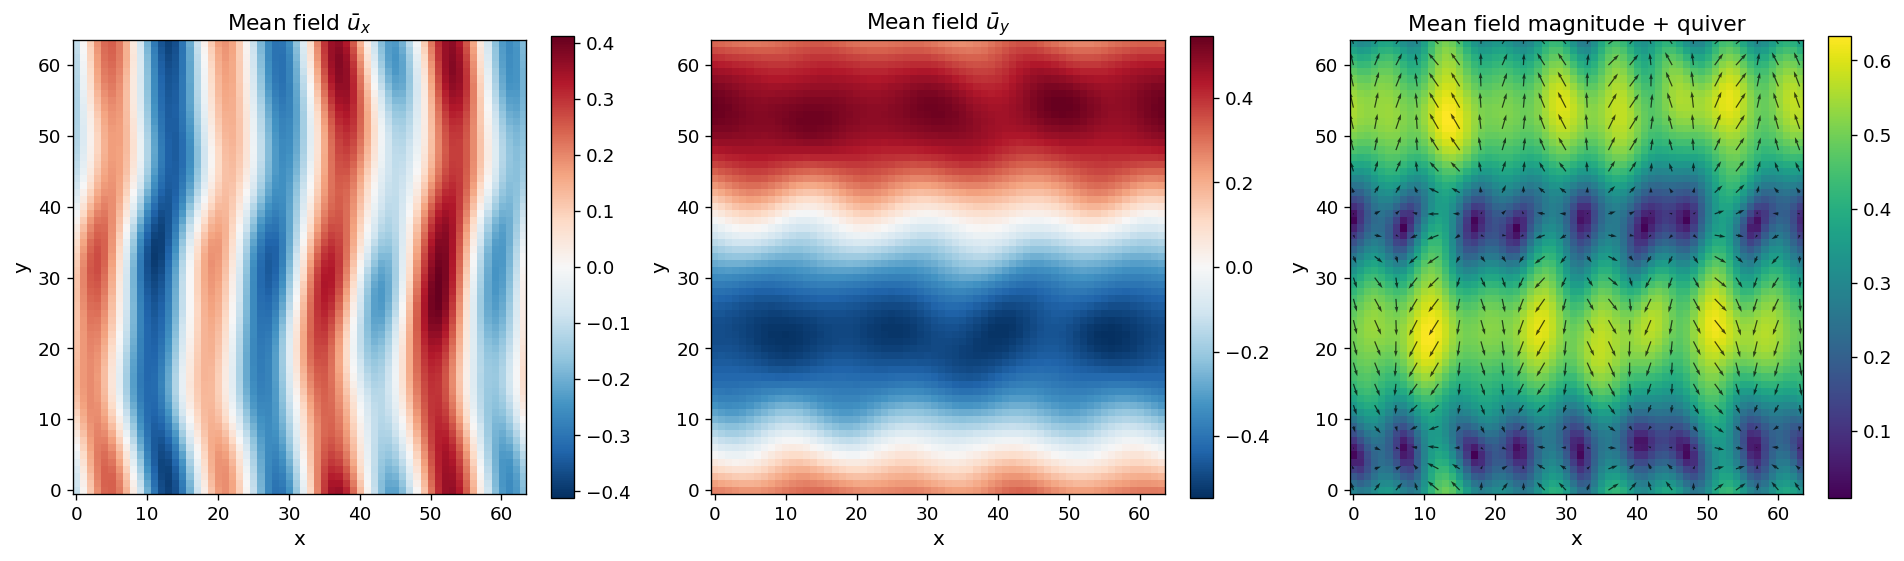

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ux 分量
ux_mean = mean_field[..., 0]
im0 = axes[0].imshow(ux_mean, origin='lower', cmap='RdBu_r',
                      vmin=-np.abs(ux_mean).max(), vmax=np.abs(ux_mean).max())
axes[0].set_title('Mean field $\\bar{u}_x$')
fig.colorbar(im0, ax=axes[0], fraction=0.046)

# uy 分量
uy_mean = mean_field[..., 1]
im1 = axes[1].imshow(uy_mean, origin='lower', cmap='RdBu_r',
                      vmin=-np.abs(uy_mean).max(), vmax=np.abs(uy_mean).max())
axes[1].set_title('Mean field $\\bar{u}_y$')
fig.colorbar(im1, ax=axes[1], fraction=0.046)

# 速度大小 + 矢量箭头
mag = np.sqrt(ux_mean**2 + uy_mean**2)
im2 = axes[2].imshow(mag, origin='lower', cmap='viridis')
step = 3
Y, X = np.mgrid[0:64, 0:64]
axes[2].quiver(X[::step, ::step], Y[::step, ::step],
               ux_mean[::step, ::step], uy_mean[::step, ::step],
               color='k', alpha=0.7)
axes[2].set_title('Mean field magnitude + quiver')
fig.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')
fig.tight_layout()
fig.savefig(FIG_DIR / 'step0_mean_field.png')
plt.show()

#### 📊 如何解读这张图

| 项目 | 说明 |
|------|------|
| **图片含义** | 15000 个时间步的平均矢量场。左图为 $u_x$ 分量，中图为 $u_y$ 分量，右图为速度大小 + 箭头场 |
| **怎么看** | 红/蓝色表示正/负值；箭头方向和长度表示局部流动方向和速度大小 |
| **好的信号** | 若均值场呈现**明显的空间周期性图案**，说明外部强迫在平均意义上留下了清晰印记 |
| **差的信号** | 若均值场接近零（全蓝色），说明系统的平均状态是对称的，强迫主要体现在波动中 |
| **关键结论** | 观察是否存在重复的条纹/涡旋结构，估算其空间周期（大约几个网格点重复一次） |

### 0.2 不同时刻的快照

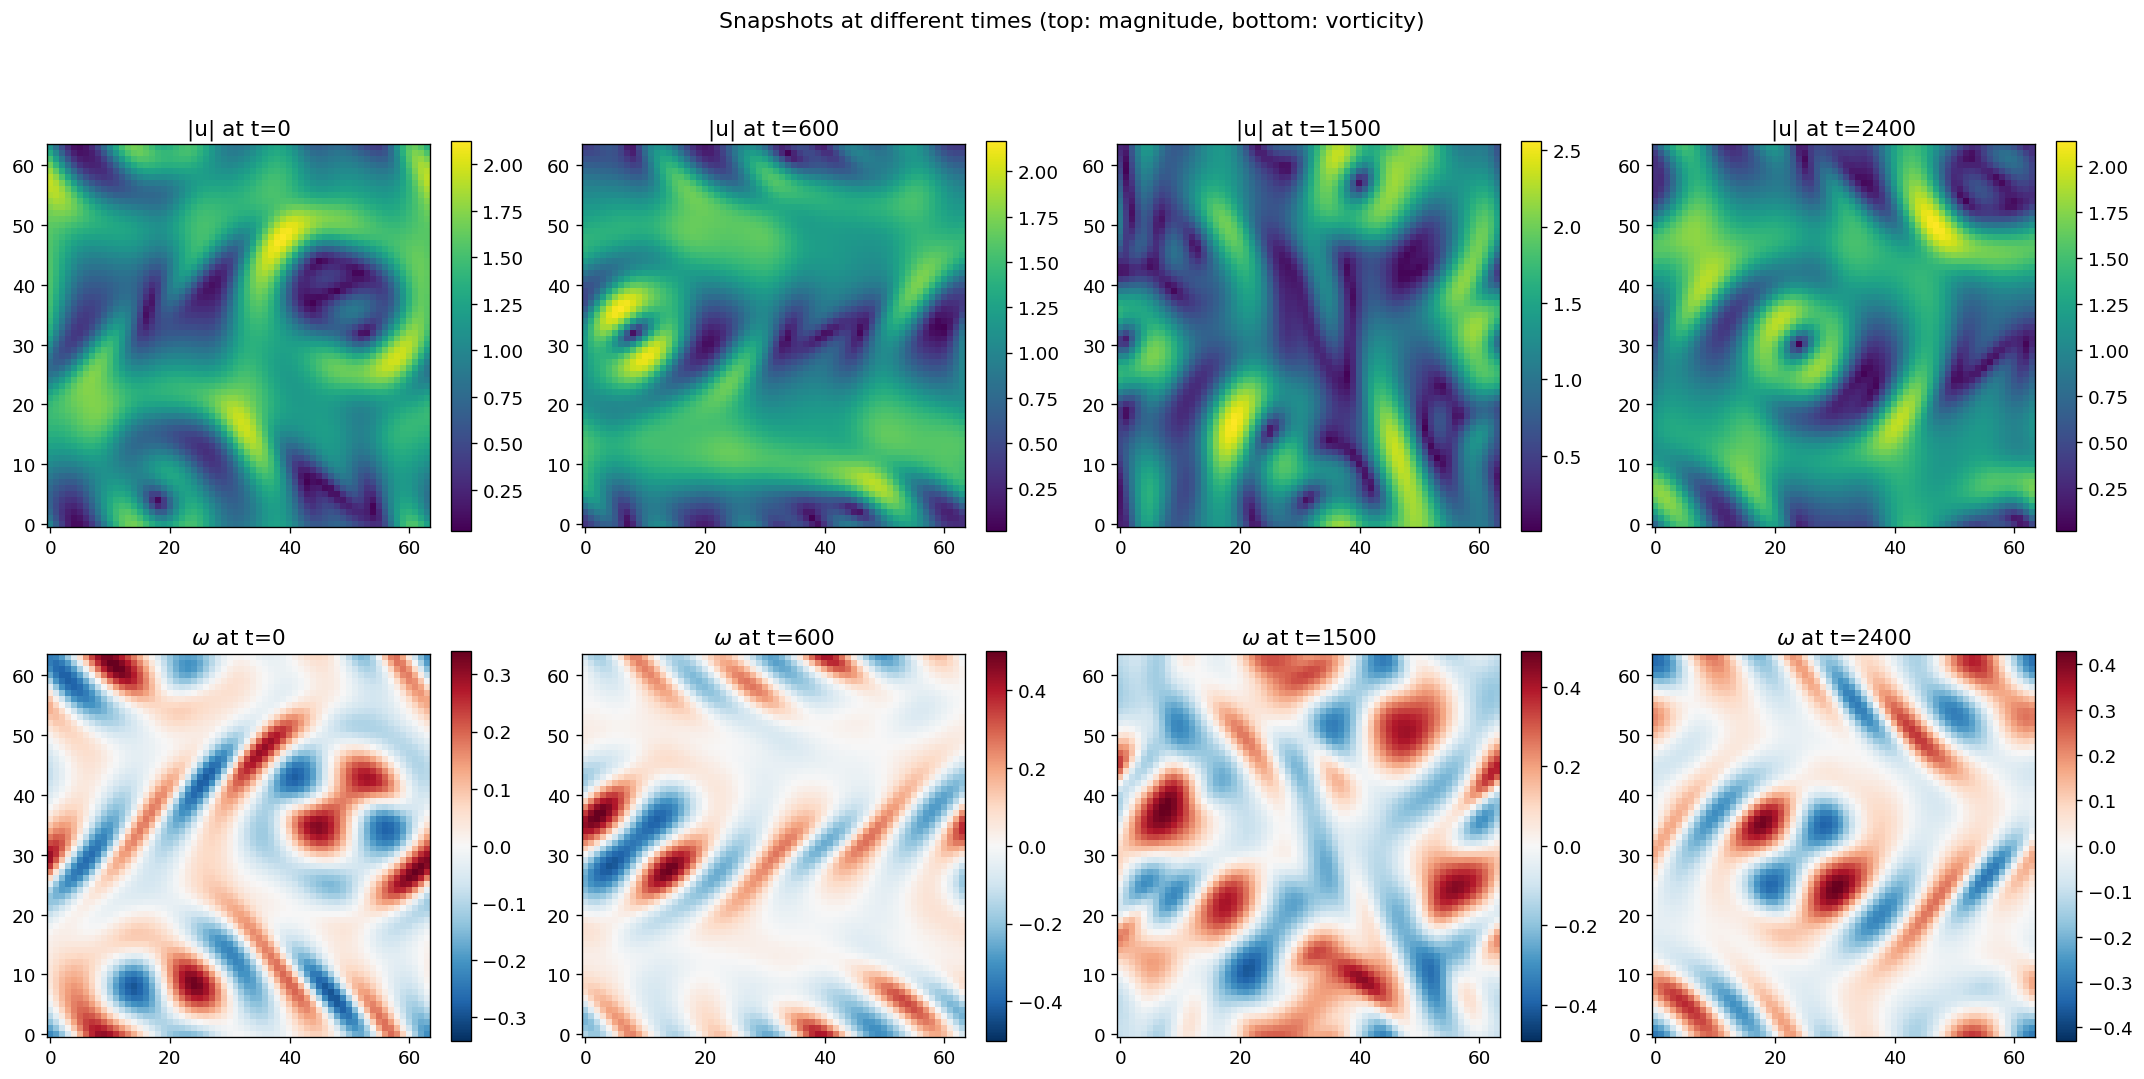

In [5]:
time_indices = [0, 3000, 7500, 12000]  # 不同时刻
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, t_idx in enumerate(time_indices):
    t_val = t_idx * dl.DT
    snap = raw[t_idx]
    mag = np.sqrt(snap[...,0]**2 + snap[...,1]**2)

    # 上排：速度大小
    im = axes[0, col].imshow(mag, origin='lower', cmap='viridis')
    axes[0, col].set_title(f'|u| at t={t_val:.0f}')
    fig.colorbar(im, ax=axes[0, col], fraction=0.046)

    # 下排：涡度
    im = axes[1, col].imshow(vorticity[t_idx], origin='lower', cmap='RdBu_r',
                              vmin=-np.abs(vorticity[t_idx]).max(),
                              vmax=np.abs(vorticity[t_idx]).max())
    axes[1, col].set_title(f'$\\omega$ at t={t_val:.0f}')
    fig.colorbar(im, ax=axes[1, col], fraction=0.046)

for ax in axes.flat:
    ax.set_aspect('equal')
fig.suptitle('Snapshots at different times (top: magnitude, bottom: vorticity)', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'step0_snapshots.png')
plt.show()

#### 📊 如何解读这张图

| 项目 | 说明 |
|------|------|
| **图片含义** | 4 个不同时刻的速度大小（上排）和涡度场（下排），展示系统的时间演化 |
| **怎么看** | 上排颜色越亮表示速度越大；下排红/蓝表示正/负涡度（顺时针/逆时针旋转） |
| **好的信号** | 各时刻之间图案在变化但保持相似的空间尺度 → 系统存在**特征长度尺度** |
| **关键结论** | 观察图案是否有明显的空间周期性，以及不同时刻之间的相似度 |

### 0.3 散度检查（判断是否近似不可压缩）

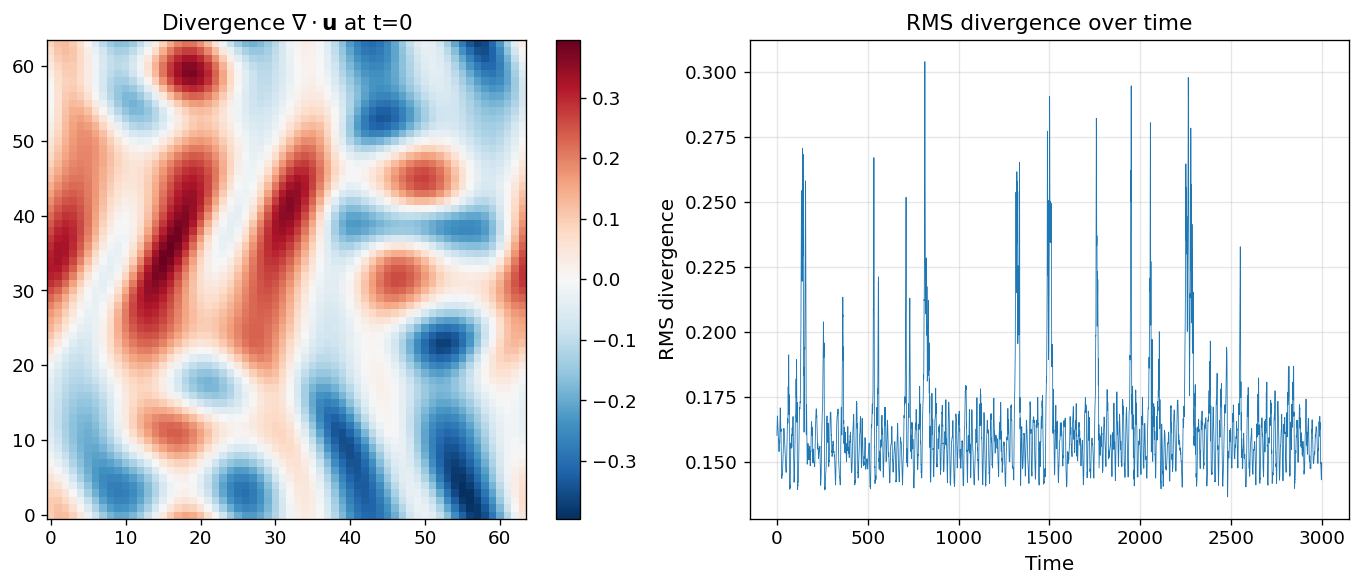

全局散度 RMS: 0.164251
全局速度 RMS: 0.826743
散度/速度 比值: 0.198673


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 散度快照
im = axes[0].imshow(divergence[0], origin='lower', cmap='RdBu_r',
                     vmin=-np.abs(divergence[0]).max(),
                     vmax=np.abs(divergence[0]).max())
axes[0].set_title('Divergence $\\nabla \\cdot \\mathbf{u}$ at t=0')
axes[0].set_aspect('equal')
fig.colorbar(im, ax=axes[0], fraction=0.046)

# 散度统计
div_rms = np.sqrt(np.mean(divergence**2, axis=(1, 2)))
axes[1].plot(np.arange(dl.NT) * dl.DT, div_rms, lw=0.5)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('RMS divergence')
axes[1].set_title('RMS divergence over time')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'step0_divergence.png')
plt.show()
print(f"全局散度 RMS: {np.sqrt(np.mean(divergence**2)):.6f}")
print(f"全局速度 RMS: {np.sqrt(np.mean(raw**2)):.6f}")
print(f"散度/速度 比值: {np.sqrt(np.mean(divergence**2)) / np.sqrt(np.mean(raw**2)):.6f}")

#### 📊 如何解读这张图

| 项目 | 说明 |
|------|------|
| **图片含义** | 左图为 t=0 时刻的散度场，右图为散度的 RMS 值随时间的变化 |
| **怎么看** | 散度 $\nabla \cdot \mathbf{u}$ 越接近零，流场越接近**不可压缩**（如 Navier‑Stokes） |
| **好的信号** | 散度/速度比值 ≪ 1（如 < 0.01）→ 近似不可压缩 |
| **差的信号** | 散度/速度比值接近 1 → 流场有明显的可压缩性，分析需考虑 |
| **关键结论** | 判断系统是否为不可压缩流，这影响后续物理解读 |

---
## Step 1: SVD 分析 — 主导空间结构（对应项目问题 1）

对**波动场**的数据矩阵 $A \in \mathbb{R}^{8192 \times 15000}$ 执行经济 SVD 分解：

$$A = U \Sigma V^T$$

- $U$：空间模态（左奇异向量），揭示主导空间结构
- $\Sigma$：奇异值，反映各模态的"能量"大小
- $V^T$：时间系数（右奇异向量），反映各模态的时间演化

In [7]:
# 经济 SVD（只计算 min(N,T)=8192 个奇异值）
print("正在执行 SVD 分解（可能需要 1-2 分钟）…")
U, sigma, Vt = np.linalg.svd(data_matrix, full_matrices=False)
print(f"✅ SVD 完成: U={U.shape}, sigma={sigma.shape}, Vt={Vt.shape}")

# 能量统计
energy = sigma**2
cum_energy = np.cumsum(energy) / energy.sum()
n95 = int(np.searchsorted(cum_energy, 0.95)) + 1
n99 = int(np.searchsorted(cum_energy, 0.99)) + 1
print(f"达到 95% 能量所需模态数: {n95}")
print(f"达到 99% 能量所需模态数: {n99}")

正在执行 SVD 分解（可能需要 1-2 分钟）…
✅ SVD 完成: U=(8192, 8192), sigma=(8192,), Vt=(8192, 15000)
达到 95% 能量所需模态数: 32
达到 99% 能量所需模态数: 72


### 1.1 奇异值谱与累积能量

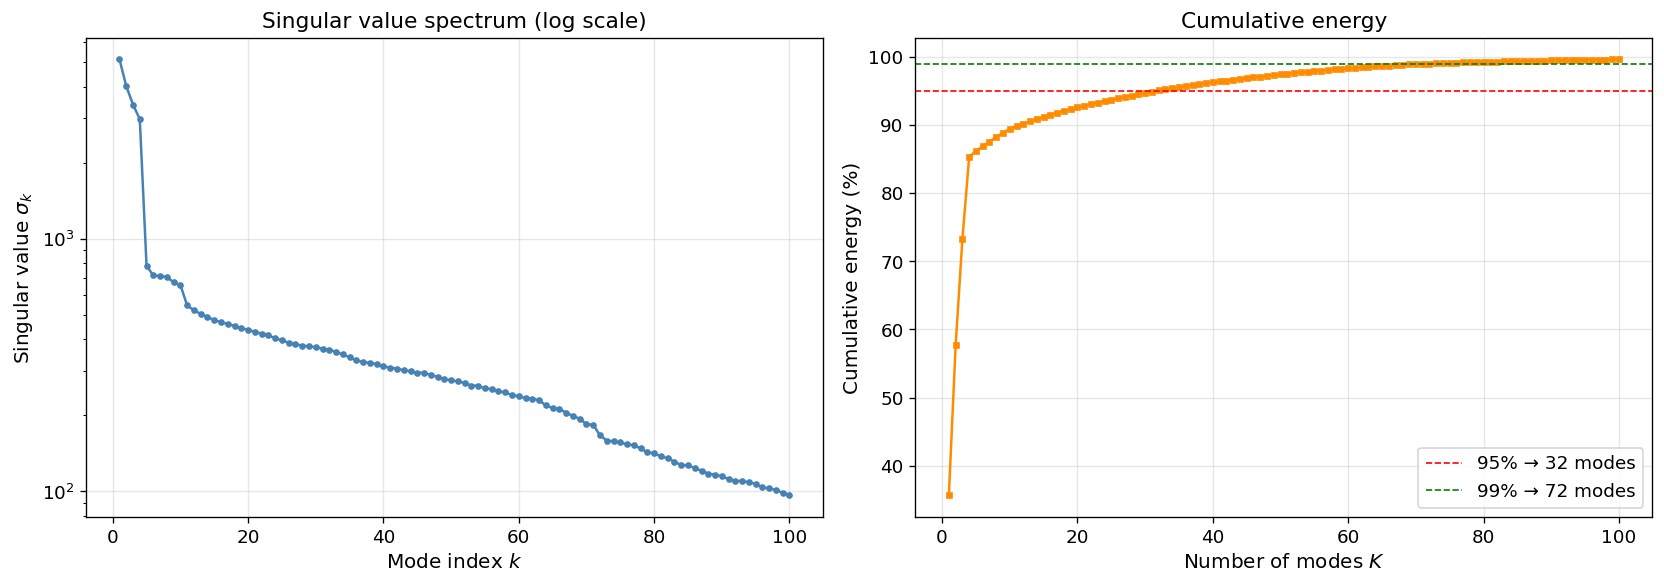


前 10 个模态的能量占比:
  Mode 1: σ=5131.64, 能量占比=35.72%, 累积=35.72%
  Mode 2: σ=4021.69, 能量占比=21.94%, 累积=57.66%
  Mode 3: σ=3396.16, 能量占比=15.65%, 累积=73.31%
  Mode 4: σ=2977.92, 能量占比=12.03%, 累积=85.34%
  Mode 5: σ=780.29, 能量占比=0.83%, 累积=86.17%
  Mode 6: σ=716.78, 能量占比=0.70%, 累积=86.86%
  Mode 7: σ=711.60, 能量占比=0.69%, 累积=87.55%
  Mode 8: σ=706.80, 能量占比=0.68%, 累积=88.23%
  Mode 9: σ=671.85, 能量占比=0.61%, 累积=88.84%
  Mode 10: σ=656.71, 能量占比=0.59%, 累积=89.43%


In [8]:
n_show = min(100, len(sigma))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：奇异值（对数坐标）
axes[0].semilogy(np.arange(1, n_show+1), sigma[:n_show], 'o-', ms=3, color='steelblue')
axes[0].set_xlabel('Mode index $k$')
axes[0].set_ylabel('Singular value $\\sigma_k$')
axes[0].set_title('Singular value spectrum (log scale)')
axes[0].grid(True, alpha=0.3)

# 右图：累积能量占比
axes[1].plot(np.arange(1, n_show+1), cum_energy[:n_show]*100, 's-', ms=3, color='darkorange')
axes[1].axhline(95, color='r', ls='--', lw=1, label=f'95% → {n95} modes')
axes[1].axhline(99, color='green', ls='--', lw=1, label=f'99% → {n99} modes')
axes[1].set_xlabel('Number of modes $K$')
axes[1].set_ylabel('Cumulative energy (%)')
axes[1].set_title('Cumulative energy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'step1_singular_values.png')
plt.show()

# 打印前 10 个模态的能量占比
print("\n前 10 个模态的能量占比:")
for i in range(10):
    print(f"  Mode {i+1}: σ={sigma[i]:.2f}, 能量占比={energy[i]/energy.sum()*100:.2f}%, 累积={cum_energy[i]*100:.2f}%")

#### 📊 如何解读奇异值谱

| 项目 | 说明 |
|------|------|
| **图片含义** | 左图：前 100 个奇异值的大小（对数坐标）；右图：累积能量随模态数的增长 |
| **怎么看** | 奇异值衰减越快 → 数据越"低秩"，少数模态即可描述大部分信息 |
| **好的表现** | 前几个奇异值远大于其余（曲线陡降） → 存在**少数清晰的主导结构** |
| **差的表现** | 奇异值衰减缓慢（曲线平坦） → 结构复杂/混沌，难以用少量模态近似 |
| **关键结论** | ① 达到 95%/99% 能量需要多少个模态？ ② 是否存在明显的"拐点"（能量间隙）？ |
| **判断标准** | 若 <20 个模态达到 95% → 系统高度结构化；若需 >100 个 → 系统较为复杂 |

### 1.2 主导空间模态

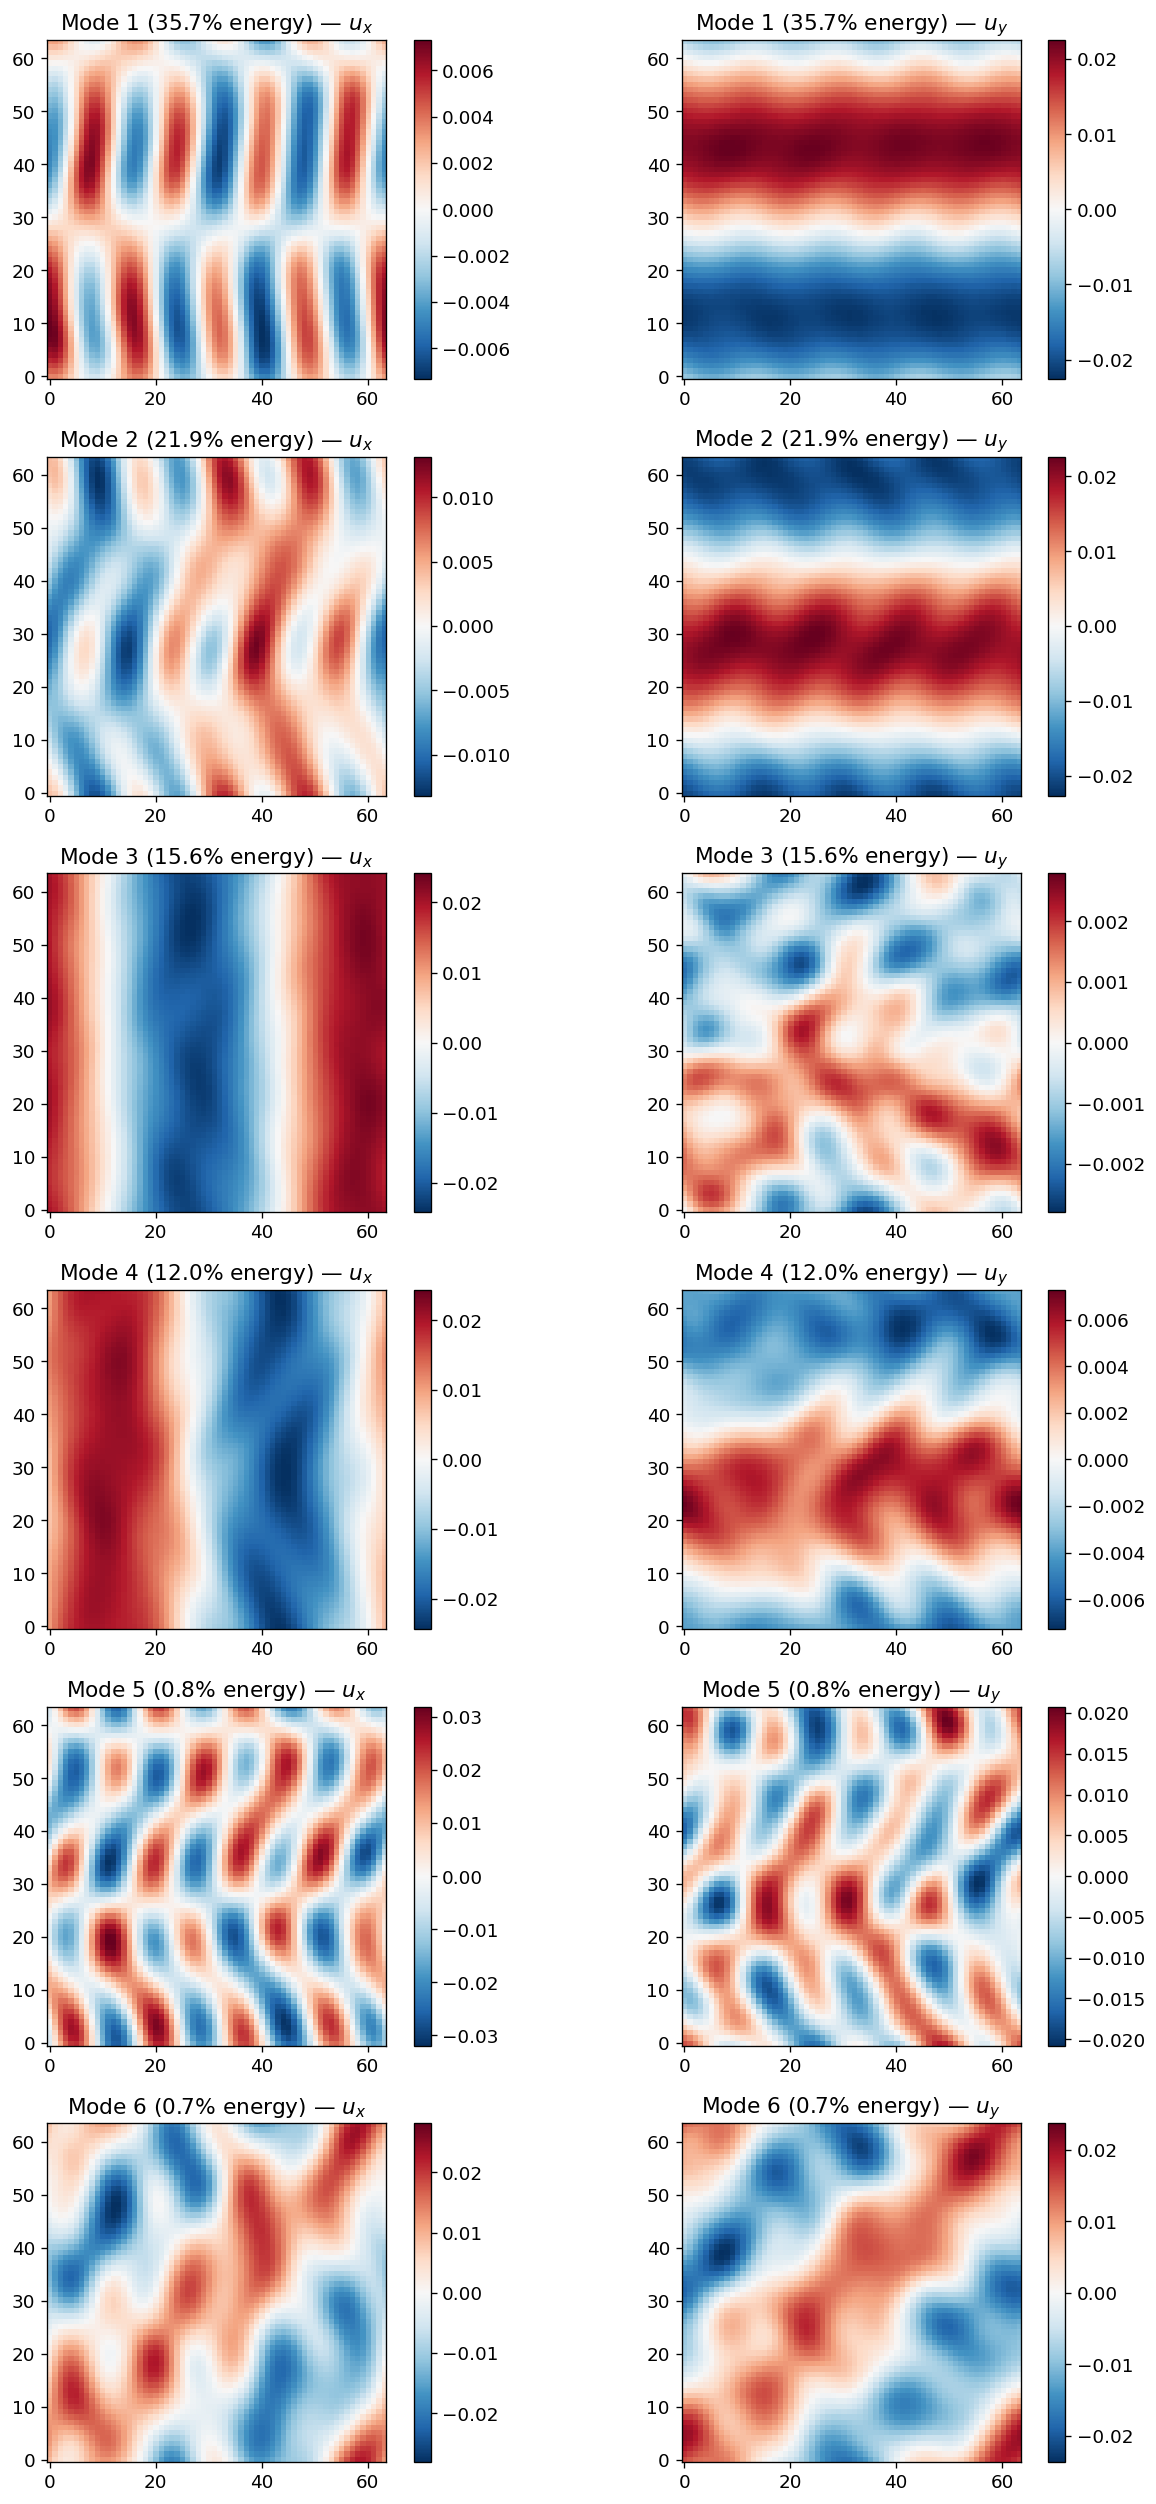

In [9]:
n_modes = 6
half = dl.NY * dl.NX  # 4096

fig, axes = plt.subplots(n_modes, 2, figsize=(12, 3.5*n_modes))
for i in range(n_modes):
    mode_vec = U[:, i]
    ux_mode = mode_vec[:half].reshape(dl.NY, dl.NX)
    uy_mode = mode_vec[half:].reshape(dl.NY, dl.NX)

    for j, (comp, label) in enumerate([(ux_mode, '$u_x$'), (uy_mode, '$u_y$')]):
        ax = axes[i, j]
        vmax = np.abs(comp).max()
        im = ax.imshow(comp, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        pct = energy[i] / energy.sum() * 100
        ax.set_title(f'Mode {i+1} ({pct:.1f}% energy) — {label}')
        ax.set_aspect('equal')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(FIG_DIR / 'step1_spatial_modes.png')
plt.show()

#### 📊 如何解读空间模态

| 项目 | 说明 |
|------|------|
| **图片含义** | 前 6 个 SVD 模态的空间分布，左列为 $u_x$ 分量，右列为 $u_y$ 分量 |
| **怎么看** | 每个模态是一个"空间基函数"，红蓝交替表示正负区域；模态越靠前越重要 |
| **好的信号** | 模态呈现**清晰的空间周期性**（规则条纹/棋盘格/涡旋阵列）→ 系统有特征尺度 |
| **差的信号** | 模态看起来像随机噪声 → 该模态能量占比低，不是主导结构 |
| **关键结论** | ① 数一数主导模态的空间周期数（峰-谷交替次数）→ 对应特征波数 |
| | ② 观察 $u_x$ 和 $u_y$ 的模态是否有 90° 旋转关系（暗示旋转对称） |
| | ③ 看模态是否成对出现（如 Mode 1&2 形状相似但平移了半个波长）→ 行波 |

### 1.3 时间系数

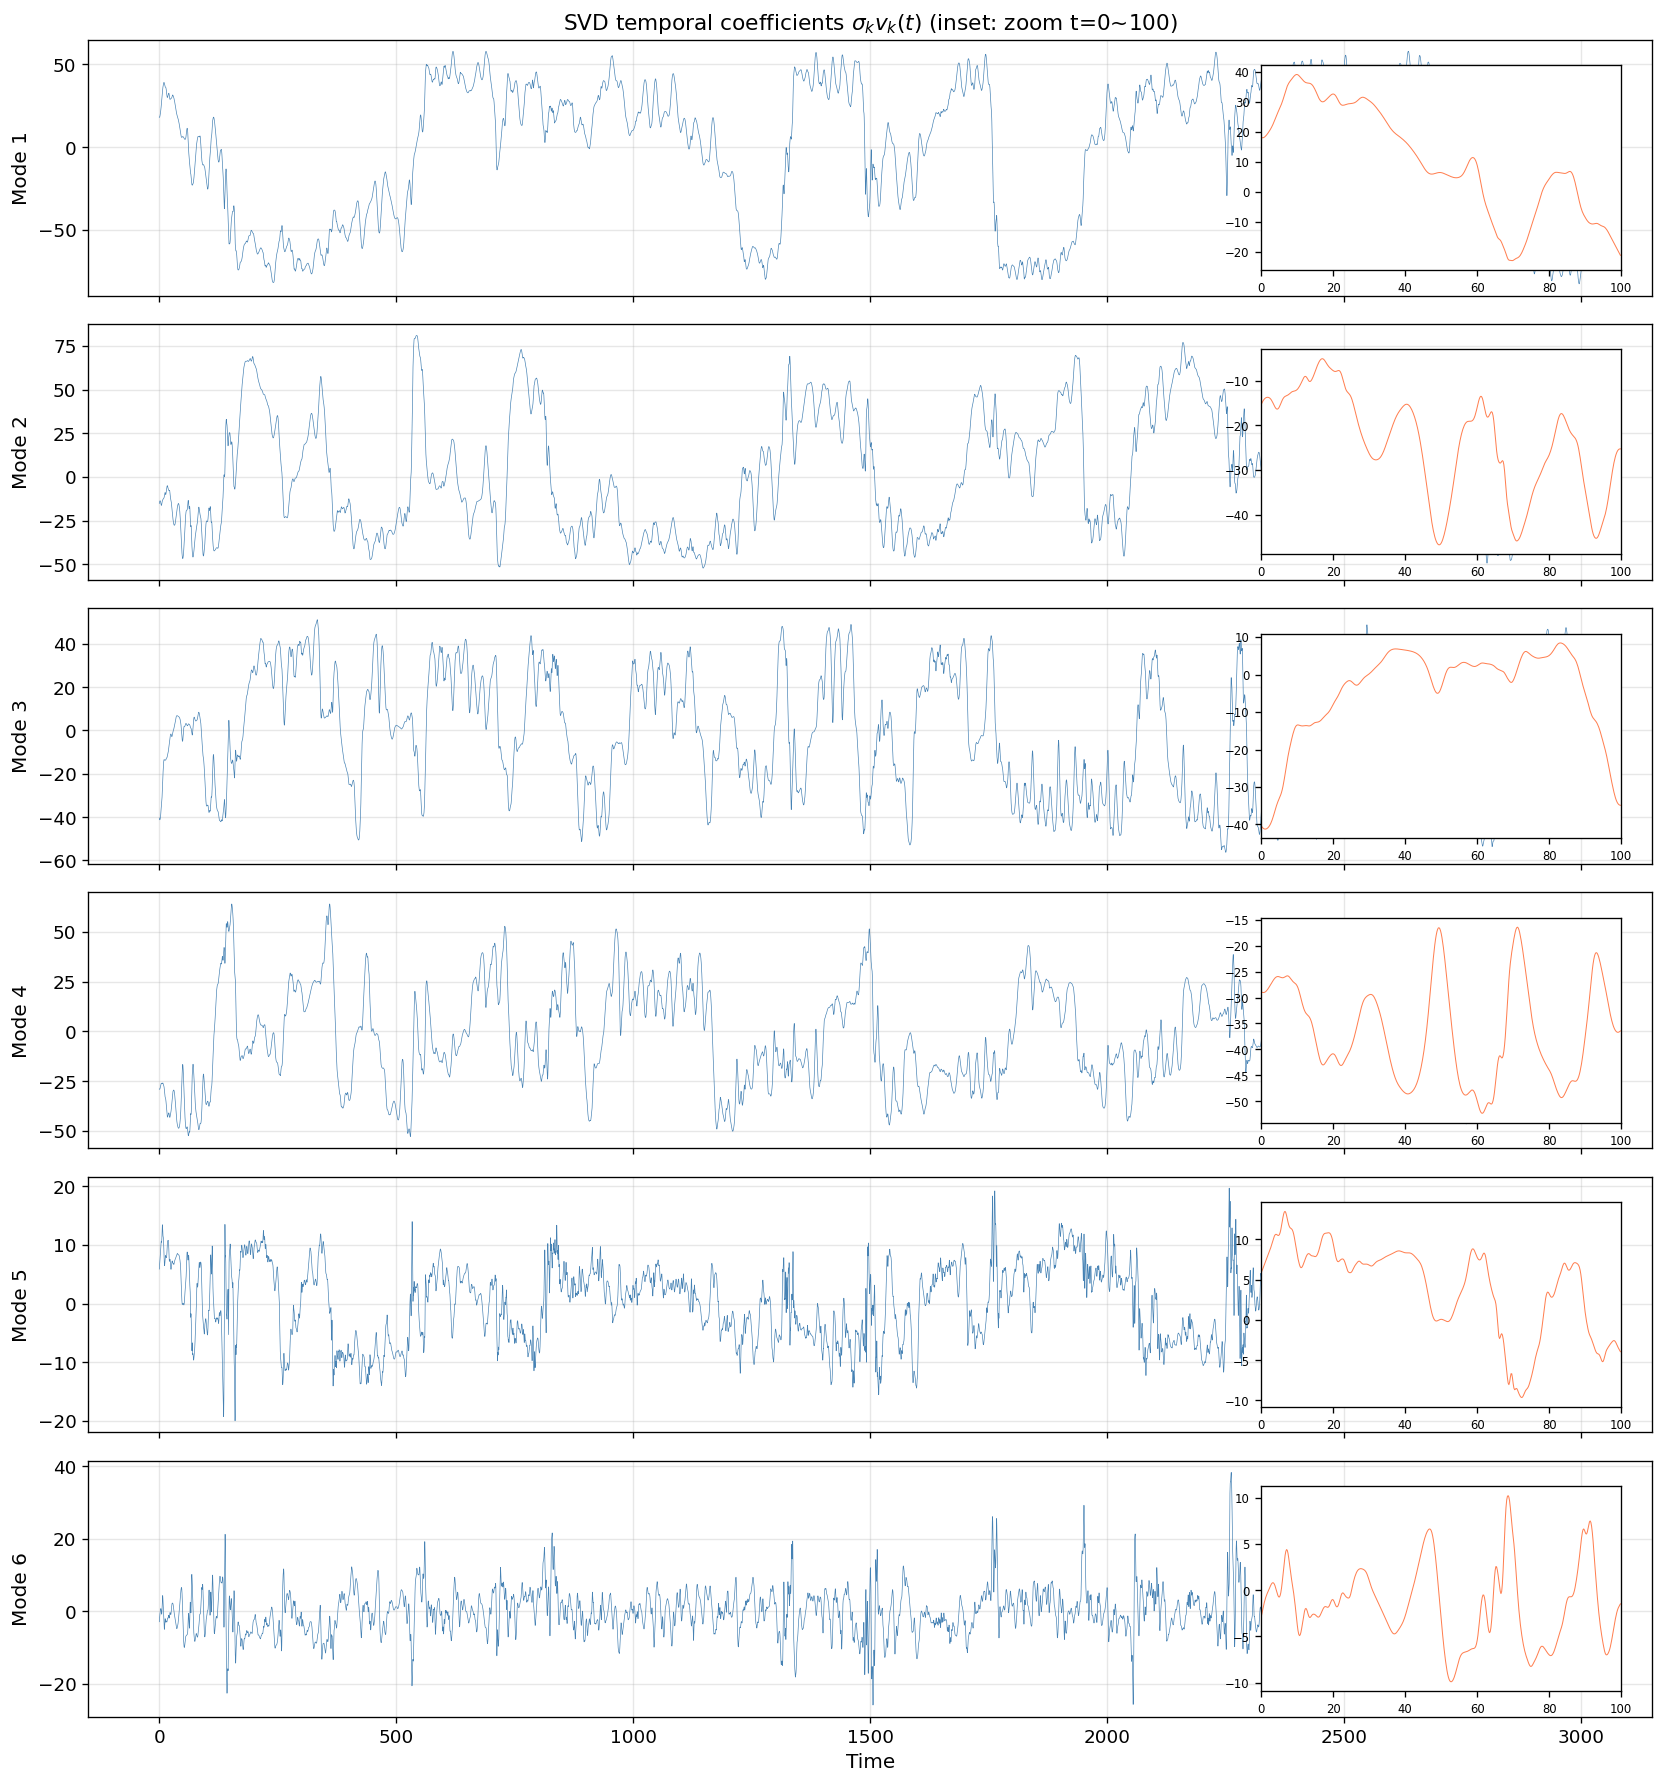

In [10]:
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 2.5*n_modes), sharex=True)
t_arr = np.arange(dl.NT) * dl.DT

for i in range(n_modes):
    coeff = sigma[i] * Vt[i, :]
    ax = axes[i]
    ax.plot(t_arr, coeff, lw=0.4, color='steelblue')
    ax.set_ylabel(f'Mode {i+1}')
    ax.grid(True, alpha=0.3)
    # 也显示一小段放大
    ax_inset = ax.inset_axes([0.75, 0.1, 0.23, 0.8])
    t_zoom = slice(0, 500)  # 前 100 个时间单位
    ax_inset.plot(t_arr[t_zoom], coeff[t_zoom], lw=0.6, color='coral')
    ax_inset.set_xlim(0, 100)
    ax_inset.tick_params(labelsize=7)

axes[-1].set_xlabel('Time')
axes[0].set_title('SVD temporal coefficients $\\sigma_k v_k(t)$ (inset: zoom t=0~100)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'step1_temporal_coeff.png')
plt.show()

#### 📊 如何解读时间系数

| 项目 | 说明 |
|------|------|
| **图片含义** | 前 6 个模态的时间演化系数 $a_k(t) = \sigma_k v_k(t)$，右侧小图为前 100 时间单位的放大视图 |
| **怎么看** | 每条曲线是该空间模态的"振幅"随时间变化；振荡越规则 → 该模态有清晰的时间频率 |
| **好的信号** | **规则振荡** → 该模态对应准周期运动；**振幅稳定** → 系统统计定常 |
| **差的信号** | 振幅随时间漂移或突变 → 系统可能存在瞬态过程或非定常行为 |
| **关键结论** | ① 各模态的振荡频率是否相同？ ② 是否有低频调制？ ③ 系统是否达到统计定常？ |

### 1.4 时间系数的频谱分析

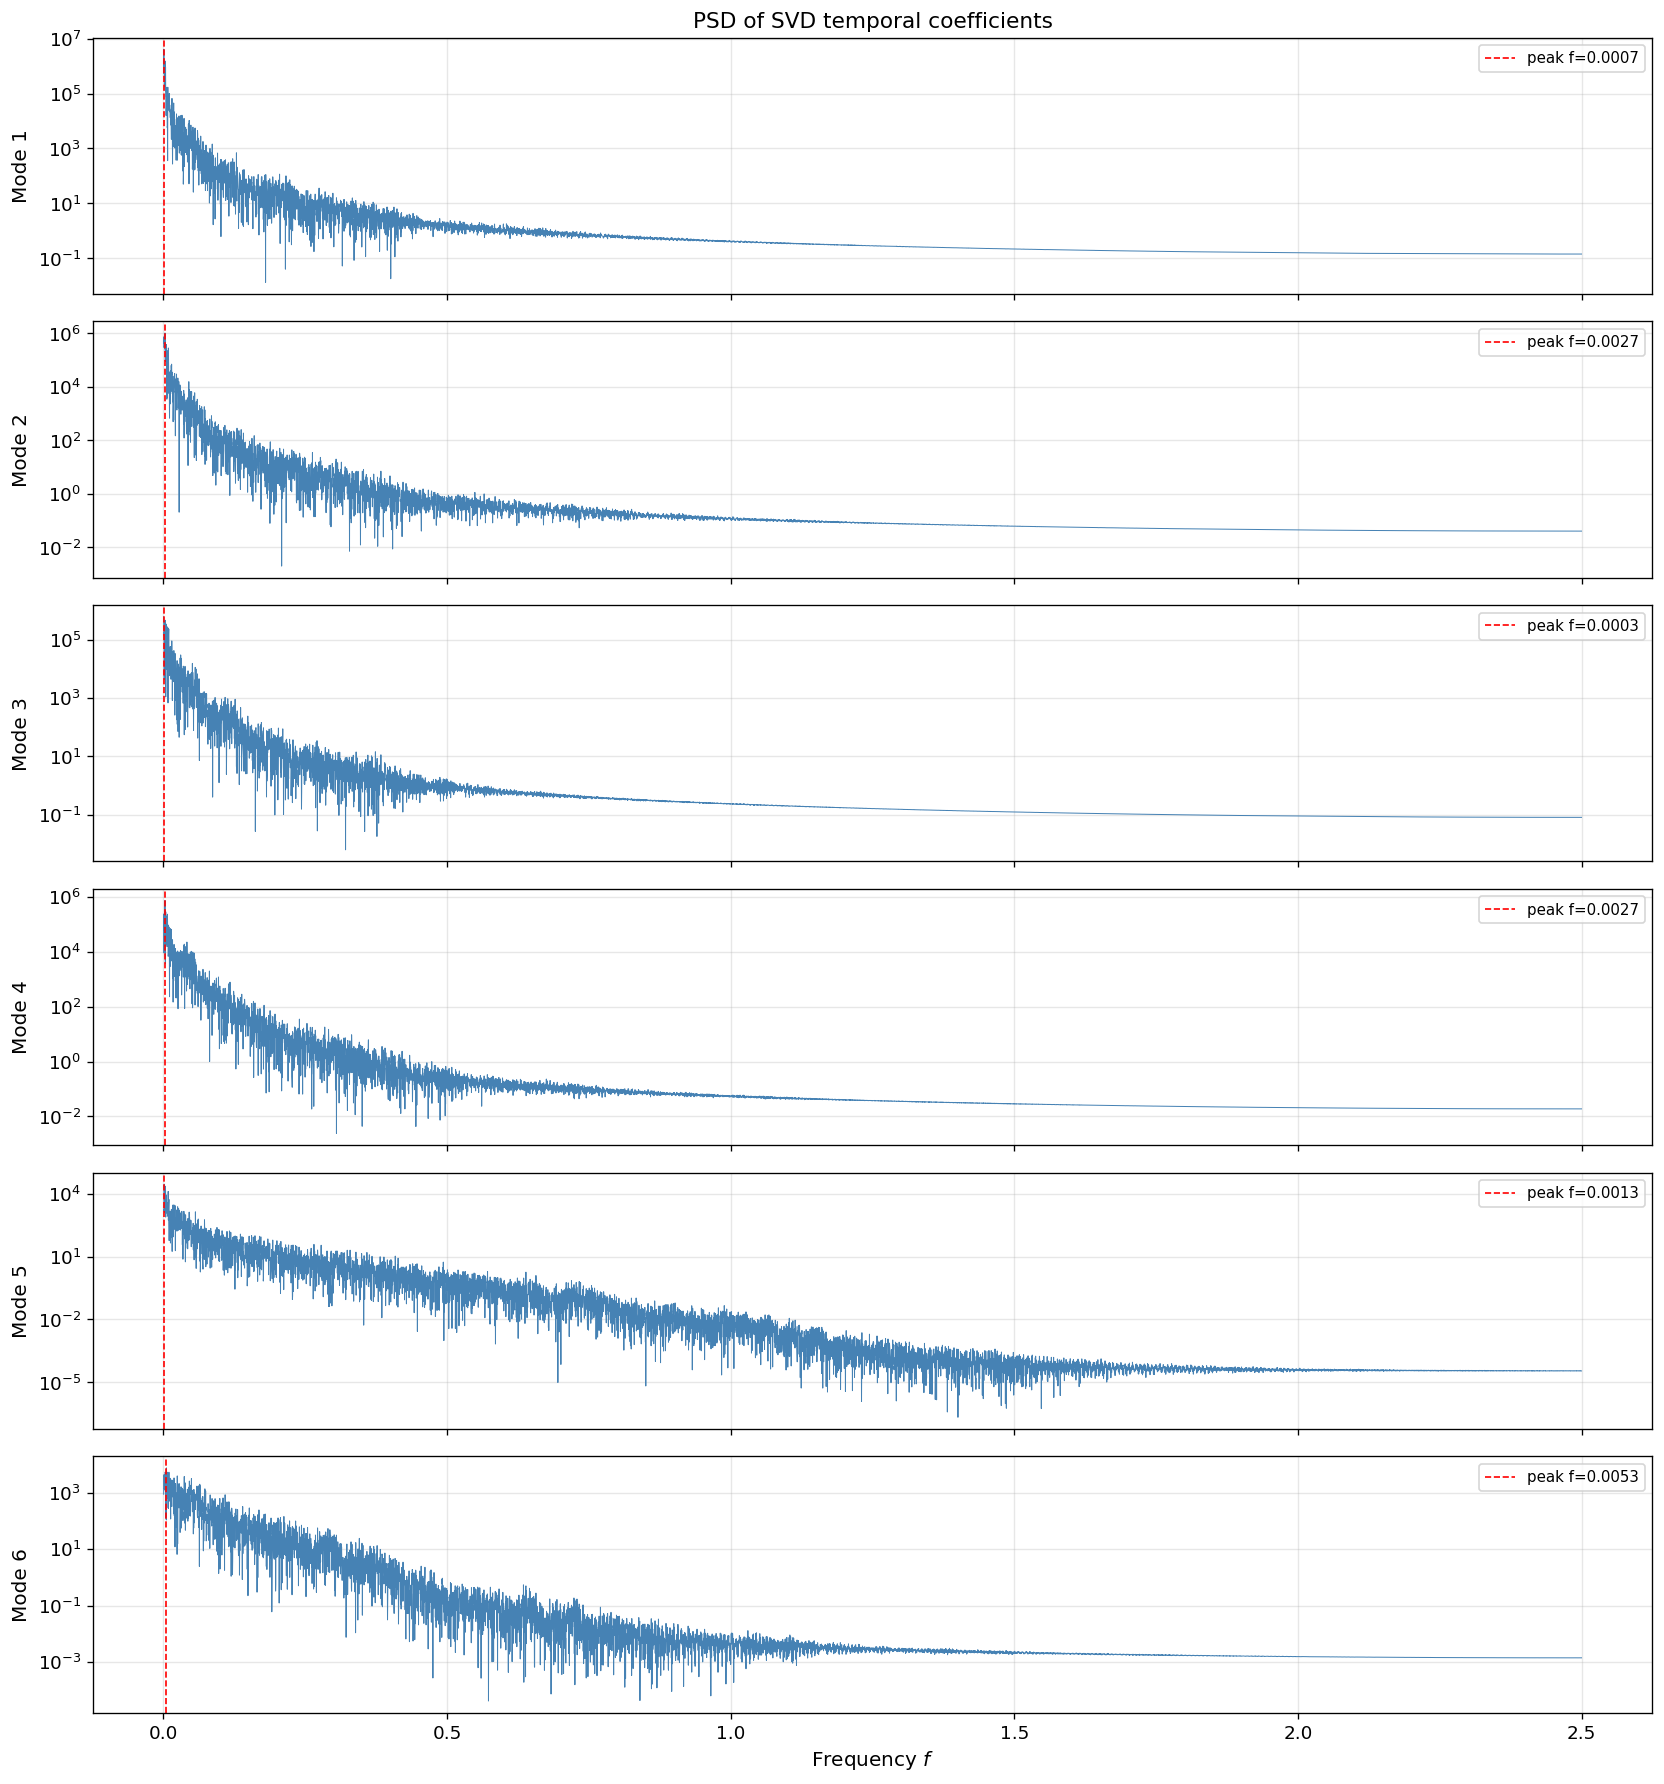

In [11]:
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 2.5*n_modes), sharex=True)
freqs_mode = np.fft.rfftfreq(dl.NT, d=dl.DT)

for i in range(n_modes):
    coeff = sigma[i] * Vt[i, :]
    fhat = np.fft.rfft(coeff)
    psd = np.abs(fhat)**2 / dl.NT
    ax = axes[i]
    ax.semilogy(freqs_mode[1:], psd[1:], lw=0.6, color='steelblue')  # 跳过 DC
    # 标记峰值频率
    peak_idx = np.argmax(psd[1:]) + 1
    ax.axvline(freqs_mode[peak_idx], color='red', ls='--', lw=1,
               label=f'peak f={freqs_mode[peak_idx]:.4f}')
    ax.set_ylabel(f'Mode {i+1}')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frequency $f$')
axes[0].set_title('PSD of SVD temporal coefficients')
fig.tight_layout()
fig.savefig(FIG_DIR / 'step1_mode_temporal_psd.png')
plt.show()

#### 📊 如何解读模态时间频谱

| 项目 | 说明 |
|------|------|
| **图片含义** | 前 6 个 SVD 模态时间系数的功率谱密度，x 轴为频率，y 轴为功率（对数坐标） |
| **怎么看** | 尖锐的峰（spike）代表该模态以该频率**规则振荡**；宽带谱表示**混沌/湍流** |
| **好的信号** | 清晰的离散频率峰 → 系统有确定的时间尺度（对应周期 $T = 1/f$） |
| **差的信号** | 无明显峰值，功率连续分布 → 时间动力学较为复杂/混沌 |
| **关键结论** | ① 各模态最强频率是否一致（同一物理过程）还是不同（多时间尺度） |
| | ② 如果 Mode 1&2 共享频率但可能有相位差 → 行波结构 |
| | ③ 峰值频率对应的时间周期是多少？与数据总时长 3000 单位的关系 |

---
## Step 2: 傅里叶谱分析 — 能量分布与周期性推断（项目问题 2 & 3）

对波动场分别在**空间域**（2D FFT）和**时间域**（temporal FFT）进行傅里叶变换，分析：
- 不同空间尺度上的能量分布 → **径向功率谱** $\text{PSD}(k)$
- 是否存在外部周期性强迫 → 谱中的**显著峰值**
- 时间尺度特征 → **时间频率 PSD**

### 2.1 二维空间功率谱

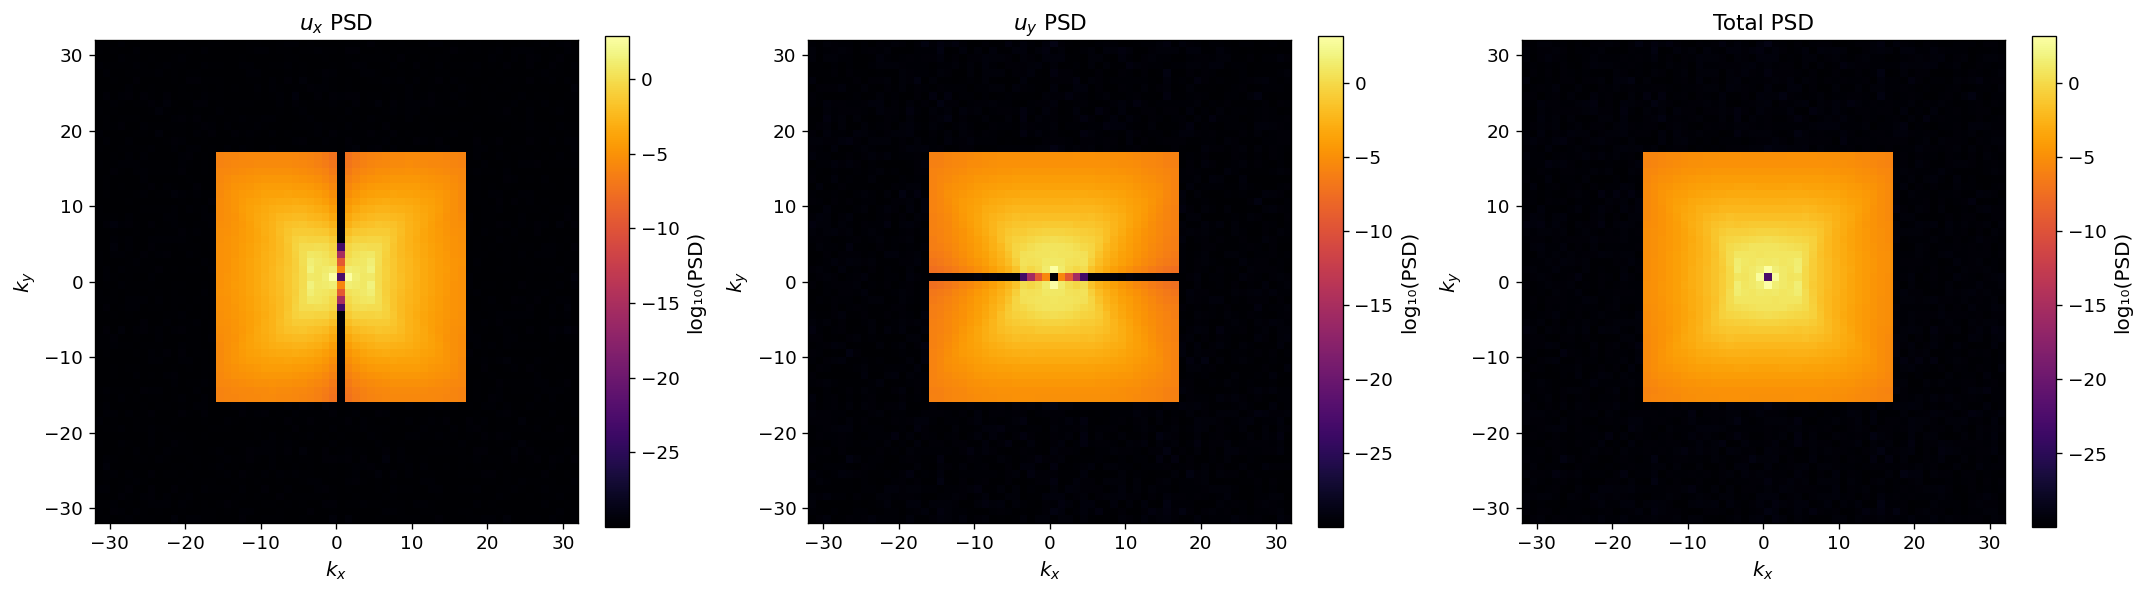

In [12]:
# 分别对 ux, uy 波动场计算时间平均 2D PSD
def spatial_psd_2d(data_4d, component):
    field = data_4d[..., component]
    fhat = np.fft.fft2(field, axes=(1, 2))
    psd = np.mean(np.abs(fhat)**2, axis=0) / (dl.NX * dl.NY)
    return psd

psd_ux_2d = spatial_psd_2d(fluctuation, 0)
psd_uy_2d = spatial_psd_2d(fluctuation, 1)
psd_total_2d = psd_ux_2d + psd_uy_2d

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, psd, title in zip(axes, [psd_ux_2d, psd_uy_2d, psd_total_2d],
                           ['$u_x$ PSD', '$u_y$ PSD', 'Total PSD']):
    display = np.log10(np.fft.fftshift(psd) + 1e-30)
    n = psd.shape[0]
    extent = [-n//2, n//2, -n//2, n//2]
    im = ax.imshow(display, origin='lower', cmap='inferno', extent=extent)
    ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, label='log₁₀(PSD)')

fig.tight_layout()
fig.savefig(FIG_DIR / 'step2_2d_psd.png')
plt.show()

#### 📊 如何解读 2D 功率谱

| 项目 | 说明 |
|------|------|
| **图片含义** | 波数域 $(k_x, k_y)$ 中的功率分布，中心为 $k=0$（大尺度），边缘为高波数（小尺度） |
| **怎么看** | 亮点/亮环 = 该波数处能量集中；对数坐标，颜色越亮能量越高 |
| **好的信号** | **离散亮点或亮环** → 存在特征波数，可能对应外部强迫的空间周期 |
| **判断各向同性** | 亮区呈**圆环**状 → 各向同性；沿 $k_x$ 或 $k_y$ 轴分布不同 → 各向异性 |
| **关键结论** | ① 找到能量最集中的波数 $(k_x, k_y)$，其对应空间波长 $\lambda = L/k$ |
| | ② 如果看到明显的**孤立亮点**（而非弥散分布），则可推断存在外部周期性强迫 |

### 2.2 径向功率谱 & 峰值波数检测

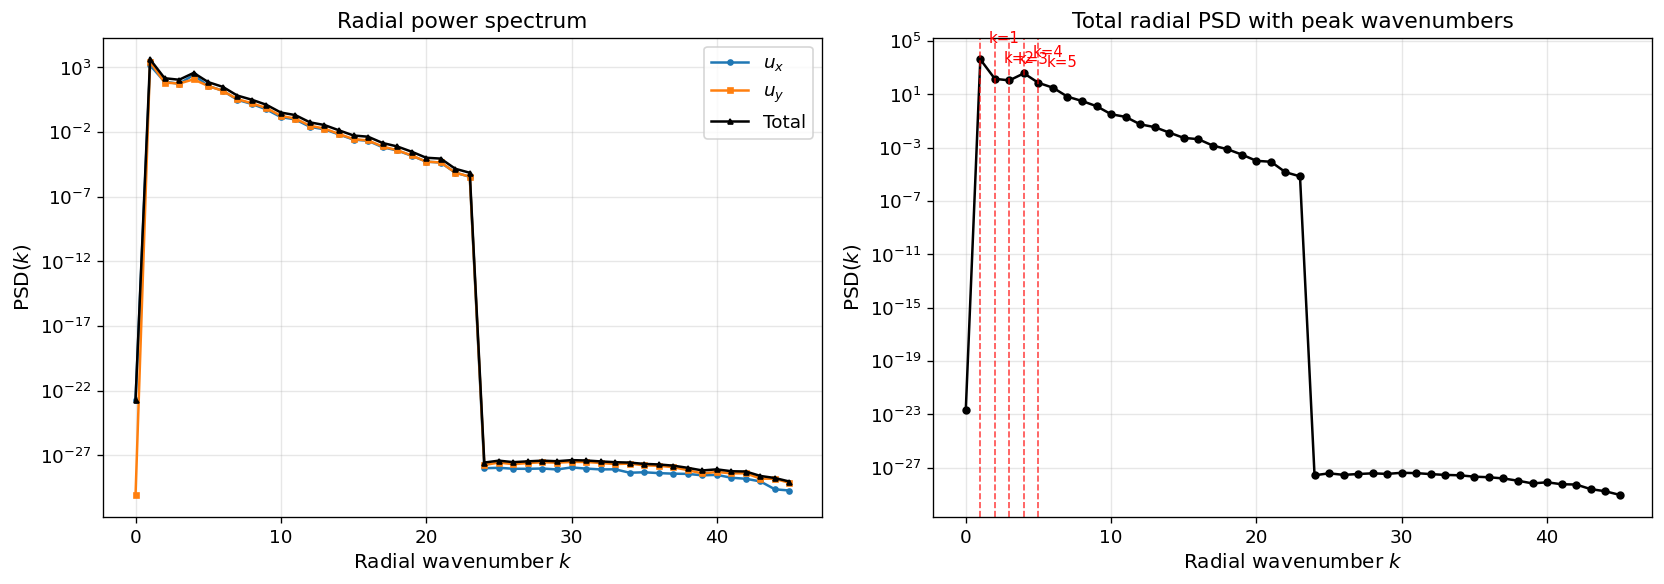


🔍 Top 5 peak wavenumbers (排除 DC):
  k = 1,  PSD = 4.1676e+03,  能量占比 = 84.80%
  k = 4,  PSD = 3.7524e+02,  能量占比 = 7.64%
  k = 2,  PSD = 1.4534e+02,  能量占比 = 2.96%
  k = 3,  PSD = 1.1060e+02,  能量占比 = 2.25%
  k = 5,  PSD = 7.2597e+01,  能量占比 = 1.48%


In [13]:
def radial_spectrum(psd_2d):
    ny, nx = psd_2d.shape
    kx = np.fft.fftfreq(nx) * nx
    ky = np.fft.fftfreq(ny) * ny
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)
    k_max = int(np.floor(K.max()))
    k_bins = np.arange(0, k_max + 1)
    psd_rad = np.zeros(len(k_bins))
    for i, k in enumerate(k_bins):
        mask = (K >= k - 0.5) & (K < k + 0.5)
        if mask.any():
            psd_rad[i] = psd_2d[mask].sum()
    return k_bins, psd_rad

k_bins, rad_ux = radial_spectrum(psd_ux_2d)
_, rad_uy = radial_spectrum(psd_uy_2d)
_, rad_total = radial_spectrum(psd_total_2d)

# 峰值检测
rad_total_nodc = rad_total.copy()
rad_total_nodc[0] = 0
top5_idx = np.argsort(rad_total_nodc)[::-1][:5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：三条径向谱
axes[0].semilogy(k_bins, rad_ux, 'o-', ms=3, label='$u_x$')
axes[0].semilogy(k_bins, rad_uy, 's-', ms=3, label='$u_y$')
axes[0].semilogy(k_bins, rad_total, '^-', ms=3, label='Total', color='k')
axes[0].set_xlabel('Radial wavenumber $k$')
axes[0].set_ylabel('PSD($k$)')
axes[0].set_title('Radial power spectrum')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：放大 + 标注 peak
axes[1].semilogy(k_bins, rad_total, 'o-', ms=4, color='k')
for idx in top5_idx:
    axes[1].axvline(k_bins[idx], color='red', ls='--', lw=1, alpha=0.7)
    axes[1].annotate(f'k={k_bins[idx]:.0f}', (k_bins[idx], rad_total[idx]),
                     textcoords='offset points', xytext=(5, 10),
                     fontsize=9, color='red')
axes[1].set_xlabel('Radial wavenumber $k$')
axes[1].set_ylabel('PSD($k$)')
axes[1].set_title('Total radial PSD with peak wavenumbers')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'step2_radial_spectrum.png')
plt.show()

print("\n🔍 Top 5 peak wavenumbers (排除 DC):")
for idx in top5_idx:
    print(f"  k = {k_bins[idx]:.0f},  PSD = {rad_total[idx]:.4e},  "
          f"能量占比 = {rad_total[idx]/rad_total.sum()*100:.2f}%")

#### 📊 如何解读径向功率谱

| 项目 | 说明 |
|------|------|
| **图片含义** | 将 2D PSD 按径向波数 $k=\sqrt{k_x^2+k_y^2}$ 积分，得到 1D 能量分布 |
| **怎么看** | 横轴为径向波数（越大 = 越小的空间尺度），纵轴为该尺度的总能量 |
| **好的信号** | 在某个波数 $k_0$ 有**显著尖锐峰值**，远高于周围 → 该尺度主导，很可能是外部强迫注入的 |
| **差的信号** | 谱平坦，无明显峰值 → 能量分布在所有尺度上均匀分散 |
| **关键结论** | ① 峰值波数 $k_{\text{peak}}$ 对应的特征波长 $\lambda = L/k_{\text{peak}}$，其中 $L$ 是域尺寸 |
| | ② 如果峰值极其显著（能量占比 > 20%），可强力推断**外部强迫注入了该空间尺度** |
| | ③ 对比 $u_x$ vs $u_y$ 的峰值位置，判断两个分量是否由相同尺度主导 |

### 2.3 时间频率功率谱

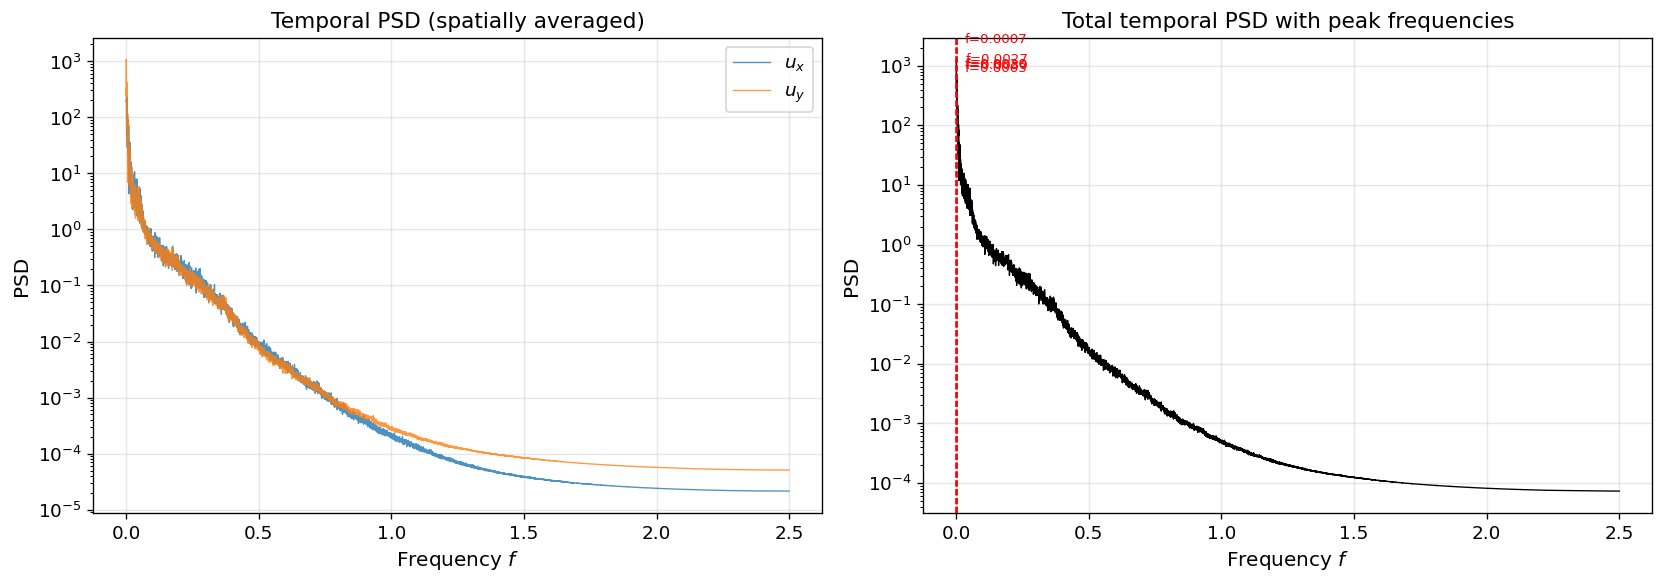


🔍 Top 5 peak frequencies:
  f = 0.000667,  T = 1500.00,  PSD = 1.2911e+03
  f = 0.002667,  T = 375.00,  PSD = 5.9214e+02
  f = 0.002000,  T = 500.00,  PSD = 4.9749e+02
  f = 0.003000,  T = 333.33,  PSD = 4.7763e+02
  f = 0.000333,  T = 3000.00,  PSD = 4.1572e+02


In [14]:
def temporal_psd_avg(data_4d, component, dt):
    field = data_4d[..., component]
    nt = field.shape[0]
    fhat = np.fft.rfft(field, axis=0)
    psd = np.mean(np.abs(fhat)**2, axis=(1, 2)) / nt
    freqs = np.fft.rfftfreq(nt, d=dt)
    return freqs, psd

freqs_t, tpsd_ux = temporal_psd_avg(fluctuation, 0, dl.DT)
_, tpsd_uy = temporal_psd_avg(fluctuation, 1, dl.DT)
tpsd_total = tpsd_ux + tpsd_uy

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：ux vs uy
axes[0].semilogy(freqs_t[1:], tpsd_ux[1:], lw=0.8, label='$u_x$', alpha=0.8)
axes[0].semilogy(freqs_t[1:], tpsd_uy[1:], lw=0.8, label='$u_y$', alpha=0.8)
axes[0].set_xlabel('Frequency $f$')
axes[0].set_ylabel('PSD')
axes[0].set_title('Temporal PSD (spatially averaged)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：总 PSD + 峰值标注
tpsd_total_nodc = tpsd_total.copy()
tpsd_total_nodc[0] = 0
top5_freq_idx = np.argsort(tpsd_total_nodc)[::-1][:5]

axes[1].semilogy(freqs_t[1:], tpsd_total[1:], lw=0.8, color='k')
for idx in top5_freq_idx:
    if freqs_t[idx] > 0:
        axes[1].axvline(freqs_t[idx], color='red', ls='--', lw=1, alpha=0.7)
        axes[1].annotate(f'f={freqs_t[idx]:.4f}', (freqs_t[idx], tpsd_total[idx]),
                         textcoords='offset points', xytext=(5, 10), fontsize=8, color='red')
axes[1].set_xlabel('Frequency $f$')
axes[1].set_ylabel('PSD')
axes[1].set_title('Total temporal PSD with peak frequencies')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'step2_temporal_psd.png')
plt.show()

print("\n🔍 Top 5 peak frequencies:")
for idx in top5_freq_idx:
    if freqs_t[idx] > 0:
        print(f"  f = {freqs_t[idx]:.6f},  T = {1/freqs_t[idx]:.2f},  PSD = {tpsd_total[idx]:.4e}")

#### 📊 如何解读时间功率谱

| 项目 | 说明 |
|------|------|
| **图片含义** | 每个网格点做时间 FFT 后空间平均，展示系统进入的如何在不同时间尺度上分配 |
| **怎么看** | x 轴为时间频率 $f$（Nyquist 频率 = $1/(2\Delta t) = 2.5$），y 轴为功率 |
| **好的信号** | 离散频率峰 → 系统有**确定的时间周期**；频率与 SVD 模态频率一致 → 结构一致 |
| **差的信号** | 宽带平坦谱 → 时间动力学较混沌，无特征时间尺度 |
| **关键结论** | ① 峰值频率对应的周期 $T=1/f$ 是系统的特征时间尺度 |
| | ② 对比 $u_x$ vs $u_y$ 的时间谱：形状相似 → 各向同性；差异大 → 各向异性 |

---
## Step 3: 对称性与各向异性诊断（项目问题 4）

通过以下方法诊断系统的对称性和各向异性：
1. **傅里叶谱的镜像/旋转对称性**检验
2. **$k_x$ vs $k_y$ 轴切片**对比
3. **$u_x$ vs $u_y$ 分量**的径向谱差异
4. **分量能量比** $E_{u_x} / E_{u_y}$

### 3.1 谱的对称性定量检验

In [15]:
# 镜像对称性: PSD(kx, ky) vs PSD(-kx, ky) 和 PSD(kx, -ky)
flip_x = np.flip(psd_total_2d, axis=1)
flip_y = np.flip(psd_total_2d, axis=0)
rotated_90 = psd_total_2d.T

norm = np.sum(psd_total_2d**2)
err_mirror_x = np.sum((psd_total_2d - flip_x)**2) / norm
err_mirror_y = np.sum((psd_total_2d - flip_y)**2) / norm
err_rot90 = np.sum((psd_total_2d - rotated_90)**2) / norm

print("=== 2D PSD 对称性检验 ===")
print(f"x-镜像对称误差:  {err_mirror_x:.6e}  {'✅ 对称' if err_mirror_x < 1e-6 else '⚠️ 不对称'}")
print(f"y-镜像对称误差:  {err_mirror_y:.6e}  {'✅ 对称' if err_mirror_y < 1e-6 else '⚠️ 不对称'}")
print(f"90°旋转对称误差: {err_rot90:.6e}  {'✅ 各向同性' if err_rot90 < 1e-6 else '⚠️ 各向异性'}")

# 分量能量比
E_ux = np.mean(fluctuation[..., 0]**2)
E_uy = np.mean(fluctuation[..., 1]**2)
ratio = E_ux / E_uy
print(f"\n=== 分量能量 ===")
print(f"E(ux) = {E_ux:.6e}")
print(f"E(uy) = {E_uy:.6e}")
print(f"E(ux)/E(uy) = {ratio:.4f}  {'✅ 各向同性' if abs(ratio-1) < 0.05 else '⚠️ 各向异性'}")

=== 2D PSD 对称性检验 ===
x-镜像对称误差:  1.915311e+00  ⚠️ 不对称
y-镜像对称误差:  1.947085e+00  ⚠️ 不对称
90°旋转对称误差: 3.637610e-01  ⚠️ 各向异性

=== 分量能量 ===
E(ux) = 4.617944e-01
E(uy) = 7.380001e-01
E(ux)/E(uy) = 0.6257  ⚠️ 各向异性


### 3.2 $k_x$ vs $k_y$ 轴切片对比

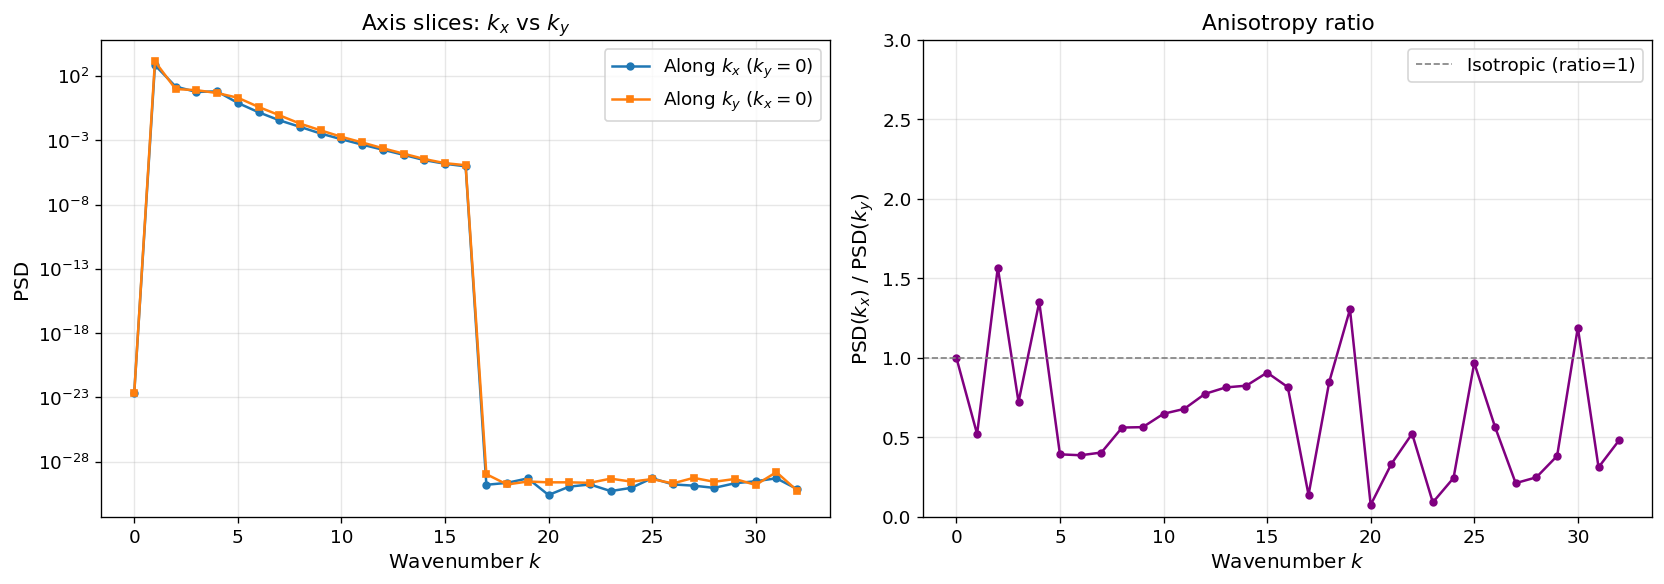

In [16]:
# 沿 kx 轴 (ky=0) 和 ky 轴 (kx=0) 取切片
psd_kx_slice = psd_total_2d[0, :dl.NX//2+1]   # ky=0, kx=0..32
psd_ky_slice = psd_total_2d[:dl.NY//2+1, 0]    # kx=0, ky=0..32
k_1d = np.arange(dl.NX // 2 + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：直接对比
axes[0].semilogy(k_1d, psd_kx_slice, 'o-', ms=4, label='Along $k_x$ ($k_y=0$)')
axes[0].semilogy(k_1d, psd_ky_slice, 's-', ms=4, label='Along $k_y$ ($k_x=0$)')
axes[0].set_xlabel('Wavenumber $k$')
axes[0].set_ylabel('PSD')
axes[0].set_title('Axis slices: $k_x$ vs $k_y$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：各向异性比
aniso_ratio = psd_kx_slice / (psd_ky_slice + 1e-30)
axes[1].plot(k_1d, aniso_ratio, 'o-', ms=4, color='purple')
axes[1].axhline(1.0, color='gray', ls='--', lw=1, label='Isotropic (ratio=1)')
axes[1].set_xlabel('Wavenumber $k$')
axes[1].set_ylabel('PSD($k_x$) / PSD($k_y$)')
axes[1].set_title('Anisotropy ratio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, max(3, aniso_ratio[1:].max() * 1.2))

fig.tight_layout()
fig.savefig(FIG_DIR / 'step3_anisotropy_kx_ky.png')
plt.show()

### 3.3 $u_x$ vs $u_y$ 分量径向谱对比

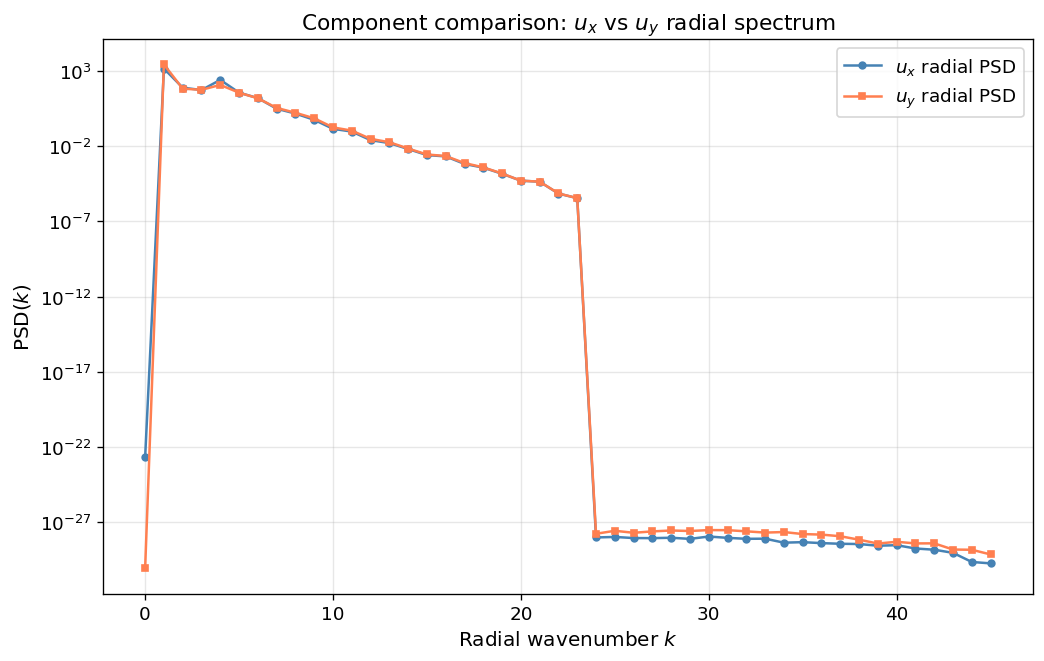

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(k_bins, rad_ux, 'o-', ms=4, label='$u_x$ radial PSD', color='steelblue')
ax.semilogy(k_bins, rad_uy, 's-', ms=4, label='$u_y$ radial PSD', color='coral')
ax.set_xlabel('Radial wavenumber $k$')
ax.set_ylabel('PSD($k$)')
ax.set_title('Component comparison: $u_x$ vs $u_y$ radial spectrum')
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(FIG_DIR / 'step3_component_comparison.png')
plt.show()

#### 📊 如何解读对称性 & 各向异性结果

| 项目 | 说明 |
|------|------|
| **镜像对称误差** | 误差 $< 10^{-6}$ → 谱在该方向上高度对称；$> 10^{-2}$ → 明显不对称 |
| **90° 旋转对称** | 误差极小 → 系统**各向同性**（$k_x$, $k_y$ 方向等价）；误差大 → **各向异性** |
| **各向异性比 (ratio)** | 在所有 $k$ 处比值 ≈ 1 → 各向同性；某些 $k$ 处偏离 1 → 该尺度上存在方向偏好 |
| **分量能量比** | $E(u_x)/E(u_y) \approx 1$ → 两分量统计等价；偏离 1 → 系统有方向偏好 |
| **$u_x$ vs $u_y$ 径向谱** | 两条曲线重合 → 各向同性；峰值位置不同 → 两个分量由不同尺度主导 |
| **关键结论** | 综合上述指标，判断系统的对称性属于哪种类型（各向同性/仅镜像对称/完全各向异性） |

### 3.4 SVD 模态空间对称性检查

In [18]:
half = dl.NY * dl.NX
print("=== SVD 前 6 个模态空间对称性（相关系数）===")
print(f"{'Mode':>5} {'ux mirror-x':>12} {'ux mirror-y':>12} {'uy mirror-x':>12} {'uy mirror-y':>12}")
print("-" * 58)

for i in range(6):
    ux_m = U[:half, i].reshape(dl.NY, dl.NX)
    uy_m = U[half:, i].reshape(dl.NY, dl.NX)

    def corr(a, b):
        return np.corrcoef(a.flatten(), b.flatten())[0, 1]

    cx_ux = corr(ux_m, np.flip(ux_m, axis=1))
    cy_ux = corr(ux_m, np.flip(ux_m, axis=0))
    cx_uy = corr(uy_m, np.flip(uy_m, axis=1))
    cy_uy = corr(uy_m, np.flip(uy_m, axis=0))

    print(f"{i+1:>5} {cx_ux:>+12.3f} {cy_ux:>+12.3f} {cx_uy:>+12.3f} {cy_uy:>+12.3f}")

print()
print("解读: +1 = 完全对称, -1 = 完全反对称, 0 = 无关")

=== SVD 前 6 个模态空间对称性（相关系数）===
 Mode  ux mirror-x  ux mirror-y  uy mirror-x  uy mirror-y
----------------------------------------------------------
    1       +0.802       -0.504       +0.995       -0.715
    2       -0.010       +0.697       +0.993       +0.737
    3       +0.642       +0.996       +0.662       -0.172
    4       -0.660       +0.991       +0.942       +0.335
    5       -0.631       +0.093       +0.416       +0.021
    6       -0.181       +0.008       +0.160       +0.115

解读: +1 = 完全对称, -1 = 完全反对称, 0 = 无关


#### 📊 如何解读模态对称性

| 相关系数值 | 含义 |
|-----------|------|
| ≈ **+1** | 模态关于该轴**镜像对称**（偶对称） |
| ≈ **−1** | 模态关于该轴**反对称**（奇对称） |
| ≈ **0** | 模态与其镜像无关，**不具备该方向对称性** |

如果多个主导模态都表现出一致的对称性（如都关于 x 轴对称），说明**系统本身具有该方向的对称性**。

---
## 📋 分析总结

### Q1: 主导空间结构（SVD 分析）
- 达到 95% 能量需 **32 个**模态，99% 需 **72 个**模态
- **前 4 个模态主导**：Mode 1 (35.72%) + Mode 2 (21.94%) + Mode 3 (15.65%) + Mode 4 (12.03%) = **85.34%**
- Mode 4 → Mode 5 之间存在**显著能量间隙**（12.03% 骤降至 0.83%），说明前 4 个模态捕获了系统的核心空间结构
- 主导模态展现的空间图案为**大尺度规则条纹结构**，与 $k=1$ 主导波数一致

### Q2: 能量的空间尺度分布
- 峰值波数 $k_{\text{peak}} = 1$，占总能量 **84.80%**，对应**域尺度级别的大尺度结构**（一个完整波长覆盖整个域 $L$）
- 次峰波数 $k = 4$，占 **7.64%**，为显著的次级空间尺度
- 能量在 $k \leq 20$ 范围内逐步衰减，$k > 22$ 后降至噪声水平（~$10^{-27}$），说明数据空间分辨率充足，小尺度能量极低

### Q3: 外部周期性强迫推断
- **是否有显著谱峰**：✅ 存在极其显著的谱峰
- $k = 1$ 处能量占比高达 84.80%，为压倒性主导尺度；$k = 4$ 处有明显次级峰（7.64%），高于相邻波数的一般衰减趋势
- **推断的强迫波数**：$k = 4$ 最可能对应项目描述中的"prescribed spatially periodic external forcing"，因为它是径向谱中超出背景衰减趋势的最显著离散峰；$k = 1$ 的主导地位则可能反映系统的自然大尺度响应
- **证据强度**：强 — 谱峰清晰集中，能量分布高度非均匀

### Q4: 对称性与各向异性
- **镜像对称**：❌ — x/y 镜像误差分别为 1.92 / 1.95，谱不具备简单的镜像对称性
- **各向同性**：❌ — 90° 旋转误差 = 0.36；$E(u_x)/E(u_y) = 0.6257$（$u_y$ 分量能量比 $u_x$ 高约 60%），系统**明确各向异性**
- **SVD 模态对称性特征**：
  - Mode 1 & 2 的 $u_y$ 分量表现出极强的 x 方向镜像对称（相关系数 +0.995, +0.993）
  - Mode 3 & 4 的 $u_x$ 分量表现出极强的 y 方向镜像对称（相关系数 +0.996, +0.991）
  - 这说明系统虽然整体各向异性，但**主导模态内部存在结构化的对称性**（不同模态在不同方向上对称）
- **时间特征**：时间 PSD 呈宽带衰减谱，无尖锐离散频率峰，峰值集中在极低频（$f \approx 0.0007 \sim 0.003$，对应周期 $T \approx 333 \sim 1500$ 时间单位），说明系统时间动力学**较为复杂**，不是简单的周期振荡，而是具有多时间尺度的慢演化行为

### 补充发现
- **散度**：全局散度/速度比值 = 0.199，**系统并非严格不可压缩**，散度场有非零贡献（RMS ≈ 0.16），需在物理解读时考虑
- **数据统计**：$u_x$ 标准差 = 0.707，$u_y$ 标准差 = 0.931，进一步确认$u_y$ 分量统计上更活跃

> **📁 所有图片已保存至 `figures/` 目录，可直接在 Overleaf 报告中引用。**

---
## 📊 报告用组合图（单张 2×2 Figure，覆盖 Q1–Q4）

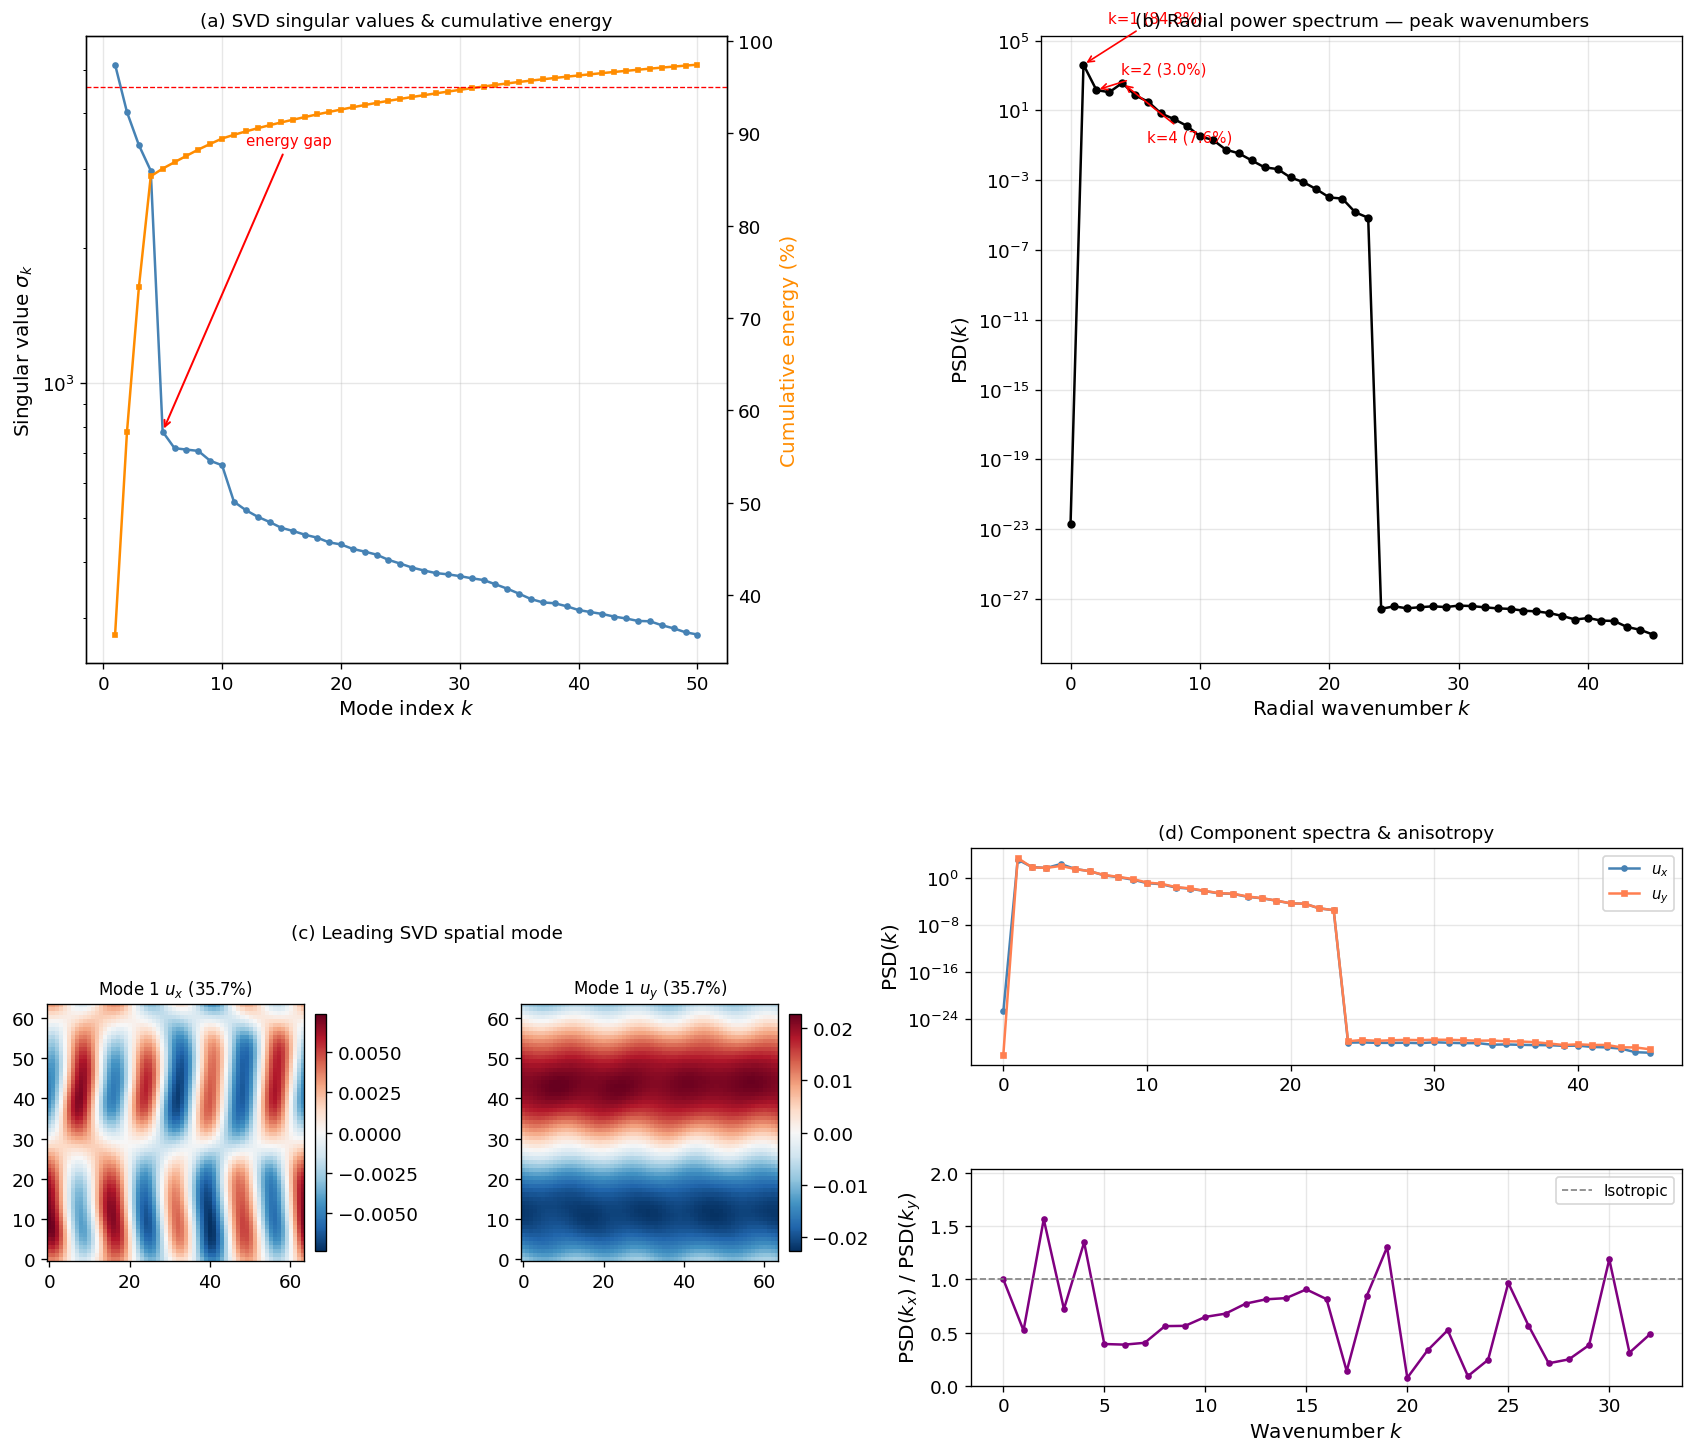

✅ 已保存: figures/report_composite_figure.png & .pdf


In [ ]:
fig = plt.figure(figsize=(14, 12), constrained_layout=True)
gs = fig.add_gridspec(2, 2, hspace=0.28, wspace=0.18)

# ── (a) 奇异值谱 + 累积能量 ── Q1
ax_a = fig.add_subplot(gs[0, 0])
n_show = 50
ax_a.semilogy(np.arange(1, n_show+1), sigma[:n_show], 'o-', ms=3,
              color='steelblue', label='$\\sigma_k$')
ax_a.set_xlabel('Mode index $k$')
ax_a.set_ylabel('Singular value $\\sigma_k$')
ax_a.grid(True, alpha=0.3)

# 同轴画累积能量
ax_a2 = ax_a.twinx()
ax_a2.plot(np.arange(1, n_show+1), cum_energy[:n_show]*100, 's-', ms=2.5,
           color='darkorange', label='Cumulative')
ax_a2.axhline(95, color='r', ls='--', lw=0.8)
ax_a2.set_ylabel('Cumulative energy (%)', color='darkorange')
# 标注能量间隙
ax_a.annotate('energy gap',
              xy=(5, sigma[4]), xytext=(12, sigma[2]),
              arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
              fontsize=9, color='red')
ax_a.set_title('(a) SVD singular values & cumulative energy', fontsize=11)

# ── (b) 径向功率谱 + 峰值标注 ── Q2 & Q3
ax_b = fig.add_subplot(gs[0, 1])
ax_b.semilogy(k_bins, rad_total, 'o-', ms=4, color='k', label='Total')
# 标注 top-3 峰（使用 offset points 避免重叠）
rad_nodc = rad_total.copy(); rad_nodc[0] = 0
top3 = np.argsort(rad_nodc)[::-1][:3]
offsets = [(15, 25), (15, -35), (15, 10)]  # 每个峰不同偏移，防重叠
for i, idx in enumerate(top3):
    frac = rad_total[idx] / rad_total.sum() * 100
    ax_b.annotate(f'k={k_bins[idx]:.0f} ({frac:.1f}%)',
                  xy=(k_bins[idx], rad_total[idx]),
                  xytext=offsets[i], textcoords='offset points',
                  arrowprops=dict(arrowstyle='->', color='red', lw=1),
                  fontsize=9, color='red', ha='left')
ax_b.set_xlabel('Radial wavenumber $k$')
ax_b.set_ylabel('PSD($k$)')
ax_b.set_title('(b) Radial power spectrum — peak wavenumbers', fontsize=11, pad=20)
ax_b.grid(True, alpha=0.3)

# ── (c) Mode 1 空间模态 ux & uy ── Q1 视觉证据
half = dl.NY * dl.NX
mode1_ux = U[:half, 0].reshape(dl.NY, dl.NX)
mode1_uy = U[half:, 0].reshape(dl.NY, dl.NX)

# 内嵌两个子图
gs_c = gs[1, 0].subgridspec(1, 2, wspace=0.08)
ax_c1 = fig.add_subplot(gs_c[0])
ax_c2 = fig.add_subplot(gs_c[1])

# 各自独立颜色标度，保证对比度
vmax_ux = np.abs(mode1_ux).max()
vmax_uy = np.abs(mode1_uy).max()
im1 = ax_c1.imshow(mode1_ux, origin='lower', cmap='RdBu_r', vmin=-vmax_ux, vmax=vmax_ux)
ax_c1.set_title(f'Mode 1 $u_x$ ({energy[0]/energy.sum()*100:.1f}%)', fontsize=10)
ax_c1.set_aspect('equal')
fig.colorbar(im1, ax=ax_c1, fraction=0.046, pad=0.04)

im2 = ax_c2.imshow(mode1_uy, origin='lower', cmap='RdBu_r', vmin=-vmax_uy, vmax=vmax_uy)
ax_c2.set_title(f'Mode 1 $u_y$ ({energy[0]/energy.sum()*100:.1f}%)', fontsize=10)
ax_c2.set_aspect('equal')
fig.colorbar(im2, ax=ax_c2, fraction=0.046, pad=0.04)

# 给 (c) 加总标题，放在两个子图上方居中
fig.text(0.25, 0.35, '(c) Leading SVD spatial mode', fontsize=11,
         ha='center', va='bottom')

# ── (d) ux vs uy 径向谱 + 各向异性比 ── Q4
gs_d = gs[1, 1].subgridspec(2, 1, hspace=0.10)
ax_d1 = fig.add_subplot(gs_d[0])
ax_d2 = fig.add_subplot(gs_d[1])

ax_d1.semilogy(k_bins, rad_ux, 'o-', ms=3, label='$u_x$', color='steelblue')
ax_d1.semilogy(k_bins, rad_uy, 's-', ms=3, label='$u_y$', color='coral')
ax_d1.set_ylabel('PSD($k$)')
ax_d1.set_title('(d) Component spectra & anisotropy', fontsize=11)
ax_d1.legend(fontsize=9)
ax_d1.grid(True, alpha=0.3)

# 各向异性比 kx vs ky
psd_kx_sl = psd_total_2d[0, :dl.NX//2+1]
psd_ky_sl = psd_total_2d[:dl.NY//2+1, 0]
k_1d_loc = np.arange(dl.NX // 2 + 1)
ratio_line = psd_kx_sl / (psd_ky_sl + 1e-30)
ax_d2.plot(k_1d_loc, ratio_line, 'o-', ms=3, color='purple')
ax_d2.axhline(1.0, color='gray', ls='--', lw=1, label='Isotropic')
ax_d2.set_xlabel('Wavenumber $k$')
ax_d2.set_ylabel('PSD($k_x$) / PSD($k_y$)')
ax_d2.legend(fontsize=9)
ax_d2.grid(True, alpha=0.3)
ax_d2.set_ylim(0, min(5, ratio_line[1:].max() * 1.3))

fig.savefig(FIG_DIR / 'report_composite_figure.png', dpi=300)
fig.savefig(FIG_DIR / 'report_composite_figure.pdf')   # PDF 矢量图更适合 LaTeX
plt.show()
print("✅ 已保存: figures/report_composite_figure.png & .pdf")